# MSIN0097: Predictive Analytics 25/26
## Individual Assignment 

Anonymous Candidate Number: TNKC5

In [50]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
)

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Class Imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

# Deep Learning
import torch

# Statistical Distributions (for hyperparameter search)
from scipy.stats import randint, uniform

# 1. Problem Framing & Success Metrics

## 1.1 Dataset Description
The dataset contains 119,390 booking records from a City Hotel and a Resort Hotel, 
spanning 32 features including lead time, length of stay, deposit type, and guest 
composition. After data cleaning (Section 3), the final dataset consists of 87,222 
records, with a post-cleaning cancellation rate of 27.53%.

## 1.2 Business Problem
Booking cancellations cause direct revenue loss and inventory inefficiency. The 
predictive objective is to classify bookings as likely to cancel or not, enabling 
targeted retention strategies before cancellation occurs.

**Target Variable:** is_canceled (1 = Cancelled, 0 = Not Cancelled)  
**Prediction Type:** Binary Classification  
**Primary Metric:** Cancellation Recall — missed cancellations carry higher operational 
costs than false alarms  
**Secondary Metric:** ROC-AUC — evaluates overall discriminative ability across thresholds  

## 1.3 Assumptions & Limitations
- Historical booking patterns assumed stable over time
- All features assumed available at prediction time
- reservation_status excluded to prevent data leakage
- Dataset covers one city hotel and one resort hotel with predominantly Portuguese guests

## 1.4 Agent Tooling Plan
Codex and Claude were used as coding agents throughout this project:

| Task | Agent Responsibility | Manual Verification |
|------|---------------------|-------------------|
| Data Cleaning | Propose imputation strategies | Validate against dataset statistics |
| EDA | Generate visualisation code | Cross-check plots for correctness |
| Feature Engineering | Suggest new features | Assess via VIF and cancellation rate analysis |
| Model Training | Recommend architectures and hyperparameters | Confirm through experimental comparison |

A full record of agent decisions is documented in the report (Appendix 7.1).

In [3]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015/7/3


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [7]:
# Codex suggestion
df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df_copy = df.copy()

## 1.5 Dataset Feature Description

The dataset contains 119,390 booking records from a City Hotel and a Resort Hotel, 
spanning 32 features. After data cleaning, the final dataset consists of 87,222 records 
with a post-cleaning cancellation rate of 27.53%. The key features used in this project are:

- **hotel**: Type of hotel, either 'Resort Hotel' or 'City Hotel'
- **lead_time**: Number of days between booking date and arrival date
- **arrival_date_year / month / week_number**: Scheduled arrival time of the guest
- **stays_in_weekend_nights / week_nights**: Number of weekend and weekday nights booked
- **adults / children / babies**: Number of guests in each category
- **meal**: Type of meal booked (e.g., BB: Bed & Breakfast, HB: Half Board)
- **country**: Country of origin of the guest
- **market_segment**: Booking channel designation (e.g., Direct, Online TA)
- **is_repeated_guest**: Whether the guest has booked before (1: Yes, 0: No)
- **previous_cancellations**: Number of previous bookings cancelled by the guest
- **agent / company**: ID of the travel agency or company that made the booking
- **adr (Average Daily Rate)**: Sum of lodging transactions divided by total staying nights
- **is_canceled**: Target variable — whether the booking was cancelled (1) or not (0)

## 1.6 Data Auditing & Cleaning

Initial auditing identified four fields with missing values:

- **Country** (0.41%): Labelled as "Unknown" to avoid mode-based statistical bias
- **Children** (0.003%): Imputed with 0, assuming no children in the booking
- **Agent** (13.69%): Imputed with 0, assuming direct bookings carry no agency involvement
- **Company** (94.31%): Dropped entirely due to negligible signal

Additional cleaning steps:
- Removed duplicate records
- Removed zero-guest bookings (invalid entries)
- Removed negative-price rows (invalid entries)

**Agent Tooling Note:** Codex suggested the initial imputation strategy. Two errors were identified and corrected:
1. `df.drop(columns=['company'])` raised a KeyError → fixed by adding `errors='ignore'`
2. Converting agent column to integer raised IntCastingNaNError → fixed by filling NaN before conversion

In [ ]:
# Data Cleaning

# Handle missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

# company is mostly missing, so drop it
# df = df.drop(columns=["company"])
df.drop(columns=['company'], errors='ignore', inplace=True)

# agent can be treated as "no agent" if missing
df["agent"] = df["agent"].fillna(0)


In [10]:
# Fix data types
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])  # transfer object into datetime

# Convert agent to integer after filling missing values
# Integers more accurately reflect the number of people or their assigned number
# df["agent"] = df["agent"].astype(int)
df["agent"] = df["agent"].fillna(0).astype(int)
df["children"] = df["children"].astype(int)

# Remove duplicates
# Duplicate rows in hotel reservation data may be due to system export errors to decrease bias
df = df.drop_duplicates()

# Remove invalid rows
# It is commercially impossible to have bookings with no guests(adults/children/babies)
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
df = df[df["adr"] >= 0]

In [11]:
# Final check
print(df.shape)
print(df.isnull().sum())
print(df.head())

(87222, 31)
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_par

In [49]:
# Dataset Summary After Cleaning

print(f"Original dataset size : {119390}")
print(f"Final dataset size    : {len(df)}")
print(f"Records removed       : {119390 - len(df)}")
print(f"Cancellation rate     : {df['is_canceled'].mean():.2%}")

Original dataset size : 119390
Final dataset size    : 87222
Records removed       : 32168
Cancellation rate     : 27.53%


**Note:** Categorical features are encoded and posterior variables removed before EDA, 
ensuring the correlation analysis in Section 2 reflects only features available at 
prediction time. Leakage prevention details are documented in Section 3.2.

In [12]:
# Encoding and Column Removal to Prevent Data Leakage

# 1. Map months(Ordinal Encoding)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

# 2. Define categorical columns for transformation
# These features contain non-numeric data that must be converted for model compatibility
categorical_cols = [
    'hotel', 'meal', 'market_segment', 'distribution_channel', 
    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type'
]

# 3. Apply One-Hot Encoding (Set drop_first=False to retain all categories)
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# 4. Create a new binary feature: 1 if country is Portugal, 0 otherwise 
# This is a hotel in Portugal, so I changed it to Portugal or another countries
df['is_portugal'] = df['country'].apply(lambda x: 1 if x == 'PRT' else 0)
df.drop(columns=['country'], inplace=True, errors='ignore')

# 5. Remove columns for data integrity and model efficiency
# 'reservation_status' and 'reservation_status_date': Dropped to prevent Data Leakage (reveals the outcome)
df_final.drop(columns=['reservation_status', 'reservation_status_date', 'country'], 
    errors='ignore', inplace=True)

# 6. Output the final feature count
print(f"Total features after encoding: {df_final.shape[1]}")
for i, col in enumerate(df_final.columns):
    print(f"{i}: {col}")

Total features after encoding: 67
0: is_canceled
1: lead_time
2: arrival_date_year
3: arrival_date_month
4: arrival_date_week_number
5: arrival_date_day_of_month
6: stays_in_weekend_nights
7: stays_in_week_nights
8: adults
9: children
10: babies
11: is_repeated_guest
12: previous_cancellations
13: previous_bookings_not_canceled
14: booking_changes
15: agent
16: days_in_waiting_list
17: adr
18: required_car_parking_spaces
19: total_of_special_requests
20: hotel_City Hotel
21: hotel_Resort Hotel
22: meal_BB
23: meal_FB
24: meal_HB
25: meal_SC
26: meal_Undefined
27: market_segment_Aviation
28: market_segment_Complementary
29: market_segment_Corporate
30: market_segment_Direct
31: market_segment_Groups
32: market_segment_Offline TA/TO
33: market_segment_Online TA
34: market_segment_Undefined
35: distribution_channel_Corporate
36: distribution_channel_Direct
37: distribution_channel_GDS
38: distribution_channel_TA/TO
39: distribution_channel_Undefined
40: reserved_room_type_A
41: reserved_r

# 2. Exploratory Data Analysis (EDA)

This section explores the dataset to identify key patterns, distributional 
characteristics, and relationships between features and the target variable 
(is_canceled). The analysis is structured into three parts:

1. **Correlation Analysis** — identify the strongest predictors and multicollinearity risks
2. **Skewness Analysis** — assess distributional imbalances that may affect model selection
3. **Cancellation vs Key Features** — examine how individual features relate to cancellation behaviour

Key findings from EDA directly motivated feature engineering decisions in Section 3 
and model selection in Section 4.

## 2.1 Correlation Analysis

A correlation heatmap of the top 20 features was generated to provide an initial 
overview of inter-feature relationships.

**Key findings:**
- **lead_time** and **deposit_type_Non-Refund** emerge as the strongest positive predictors of cancellation
- **required_car_parking_spaces** acts as a strong negative predictor, consistent with the hypothesis that guests requiring parking demonstrate higher arrival intent
- High correlation between **market_segment_Direct** and **distribution_channel_Direct** (r = 0.92) signals significant multicollinearity → addressed through VIF analysis in Section 3.2

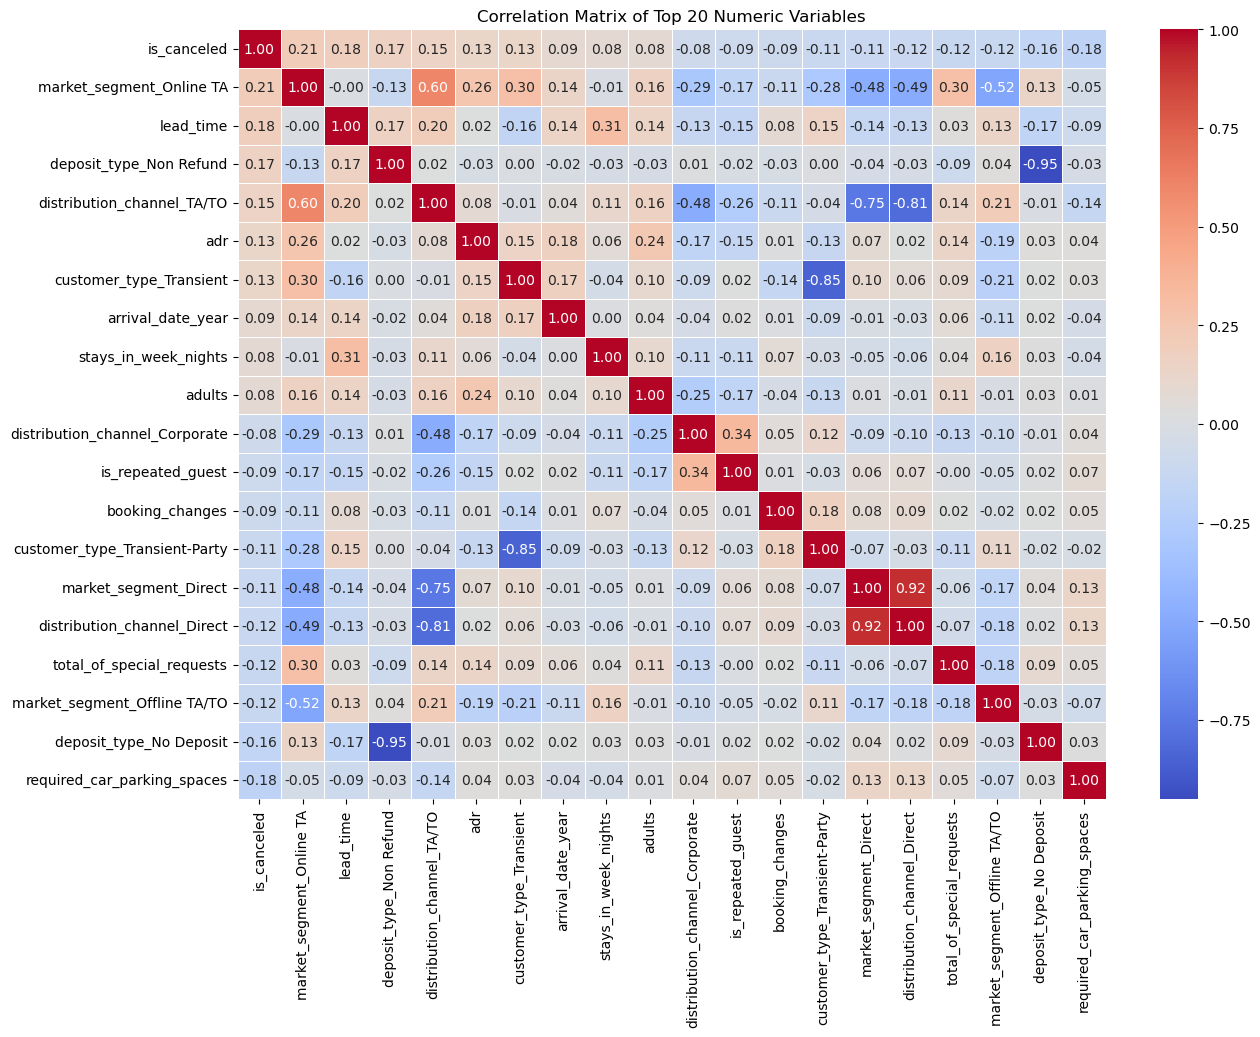

In [13]:
# Correlation heatmap for top 20 features

# 1. Select the top 20 features based on their correlation with the target
correlations = df_final.corr()['is_canceled'].sort_values(ascending=False)
top_features = correlations.head(10).index.tolist() + correlations.tail(10).index.tolist()
top_features = list(dict.fromkeys(top_features))  # Ensure 20 unique features

# 2. Calculate the full correlation matrix for these 20 features
# This shows how every feature relates to every other feature
top_corr_matrix = df_final[top_features].corr()

# 3. Plot the Matrix Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(top_corr_matrix, 
            annot=True,      # Show the numeric values
            cmap='coolwarm', # Red-Blue color scale
            fmt=".2f",       # Round to 2 decimal places
            linewidths=0.5)  # Add grid lines for clarity

plt.title('Correlation Matrix of Top 20 Numeric Variables')
plt.show()

## 2.2 Skewness Analysis

Skewness analysis was conducted to identify distributional imbalances that could 
bias tree-based splitting criteria.

**Key findings:**
- **previous_cancellations** (34.33), **babies** (21.13), and **days_in_waiting_list** (19.47) exhibit severe right-skewness
- Even continuous variables such as **adr** (11.02) contain extreme outliers
- All skewness values exceed 10, confirming heavily non-normal distributions

**Implications:**
- Justifies binning and transformation decisions in Section 3
- Further supports the selection of tree-based models (Random Forest, XGBoost) which handle non-normal distributions more robustly than linear alternatives

Features with Skewness > 1:
previous_cancellations            34.328086
babies                            21.127463
previous_bookings_not_canceled    20.455229
adults                            20.397068
days_in_waiting_list              19.466356
adr                               11.020018
dtype: float64


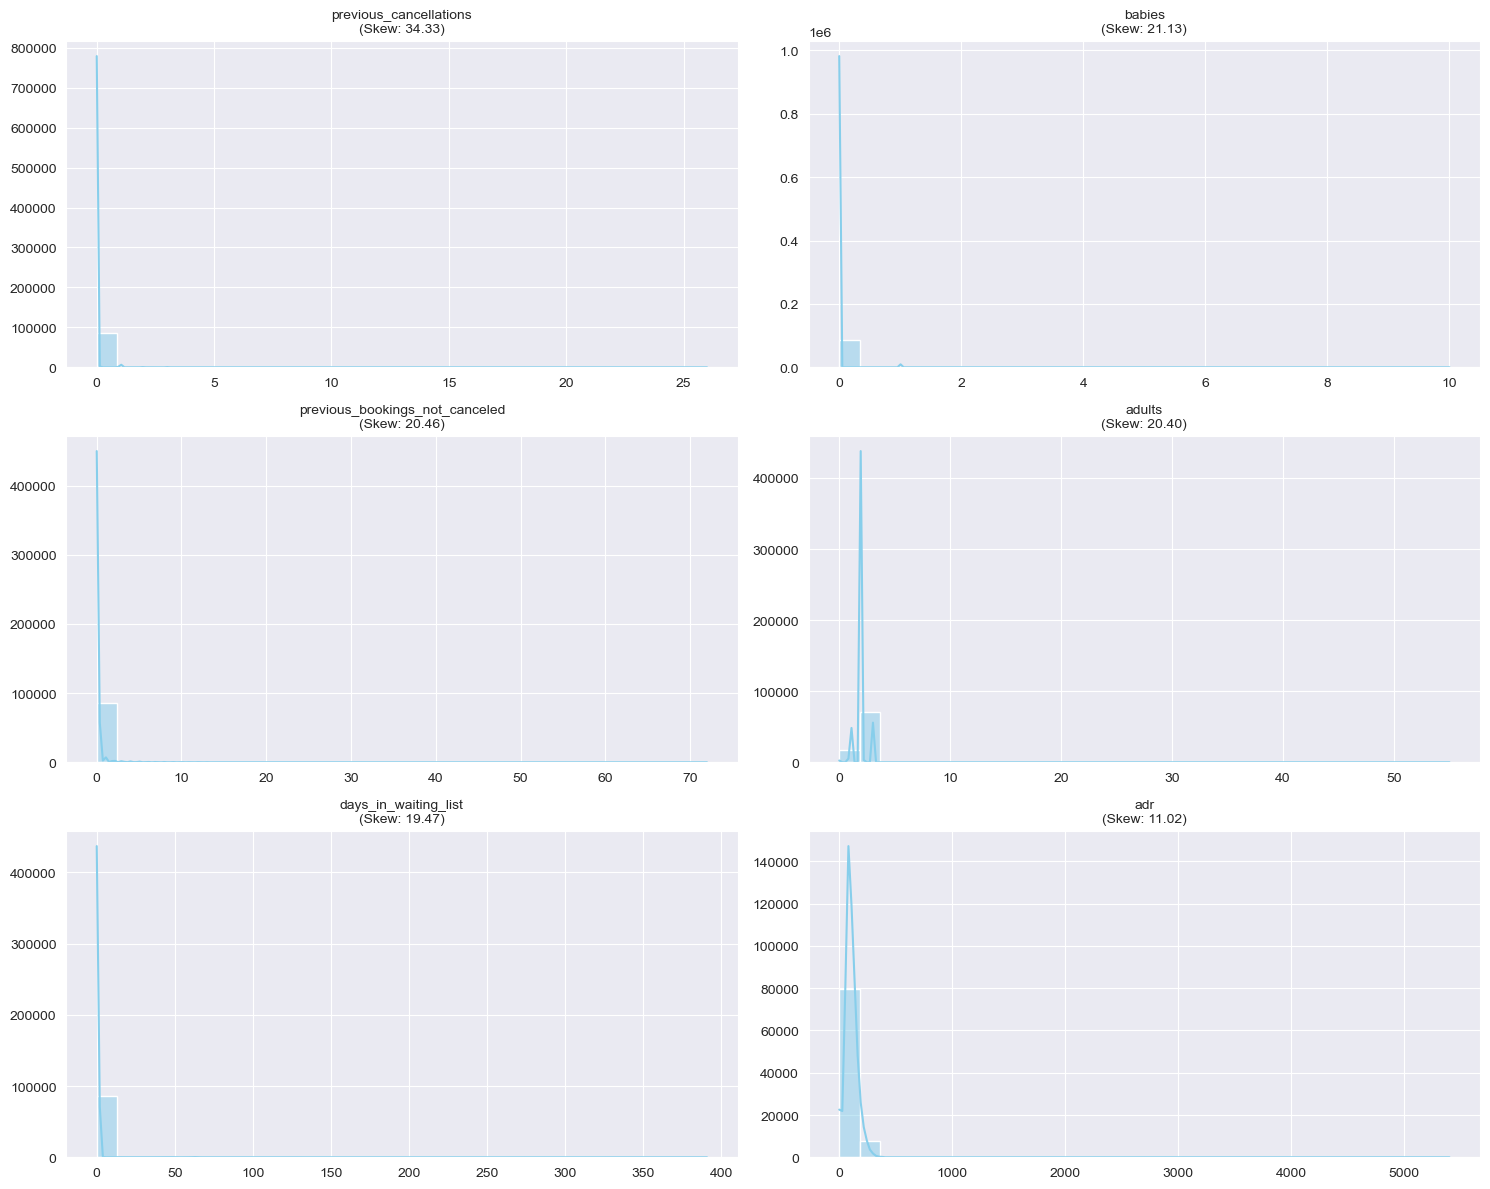

In [14]:
# Check the skewed features

# Set the visual style to a dark grid for clearer distribution patterns
sns.set_style("darkgrid")

# 1. Find all numeric features
numeric_cols = df_final.select_dtypes(include=[np.number]).columns

# 2. Calculate the skewness and filter out features with a skewness greater than 10
skewness_series = df_final[numeric_cols].skew()
highly_skewed = skewness_series[abs(skewness_series) > 10].sort_values(ascending=False)

print("Features with Skewness > 1:")
print(highly_skewed)

# 3. Display all plots
num_features = len(highly_skewed)
cols_per_row = 2
rows = (num_features + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(highly_skewed.index):
    plt.subplot(rows, cols_per_row, i + 1)
    sns.histplot(df_final[col], kde=True, color='skyblue', bins=30)
    plt.title(f'{col}\n(Skew: {highly_skewed[col]:.2f})', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## 2.3 Cancellation vs Key Features

Three sets of visualisations examine how individual features relate to cancellation 
behaviour, directly motivating feature engineering decisions in Section 3.

### Figure 3 — Monthly Cancellation Trend

**Purpose:** Examine seasonal patterns in cancellation volume to identify whether 
time of year influences cancellation behaviour.

**Key Findings:**
- Cancellations peak in August (~3,600), the highest volume month of the year
- January records the lowest cancellation volume (~1,000)
- A clear summer surge pattern is visible from June to September
- The trend suggests speculative bookings made far in advance drive peak season cancellations
- Directly motivated the creation of **is_peak_season** in Section 3.1, capturing the elevated cancellation risk during summer months

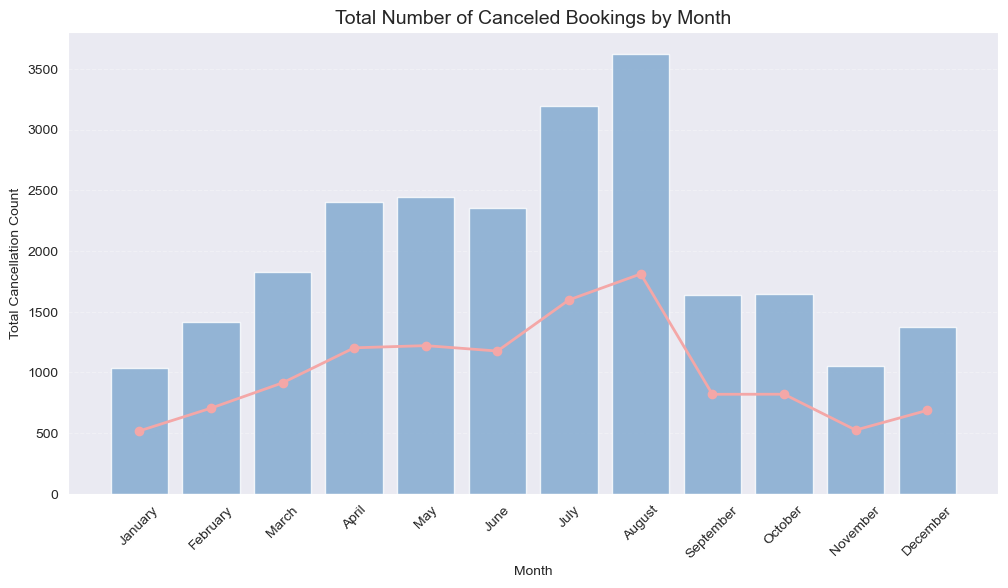

In [15]:
# Number of booking cancellation vs key features

# Cancelization vs Month
plt.figure(figsize=(12, 6))

# Define month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Calculate the total number of cancellations each month and force the data to be sorted in monthly order
cancel_counts = df[df['is_canceled'] == 1].groupby('arrival_date_month').size().reset_index(name='count')

# Define the trendline value: means of the total for each month
half_count_trend = cancel_counts['count'] * 0.5

# Barplot
sns.barplot(
    data=cancel_counts,
    x="arrival_date_month",
    y="count",
    color="#6FA8DC",
    alpha=0.8
)

# Trend line
plt.plot(
    range(len(cancel_counts)), 
    half_count_trend, # means
    marker="o", 
    color="#F4A7A7", 
    linewidth=2, 
    label="Median-based Trend (50%)"
)

plt.title("Total Number of Canceled Bookings by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Cancellation Count")
plt.xticks(range(len(month_order)), month_order, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Figure 4 — Cancellation Analysis vs Key Features (I)

**Purpose:** Examine how lead time, deposit type, special requests, past cancellations, 
market segment, and customer type relate to cancellation behaviour.

**Key Findings:**
- **Lead Time KDE:** Cancelled bookings exhibit higher density at longer lead times, establishing advance booking duration as a primary cancellation risk signal → motivated **lead_time_group** in Section 3.1
- **Deposit Type:** Non Refund bookings carry a disproportionately high cancellation rate — a counter-intuitive finding likely explained by rigid group booking policies where single changes trigger bulk cancellations
- **Special Requests:** Strong negative correlation with cancellation rate — guests who personalise their stay demonstrate stronger booking commitment → retained as **total_of_special_requests** in final feature set
- **Past Cancellations:** High-risk outliers with multiple prior cancellations represent the most volatile segment → retained as **previous_cancellations**
- **Market Segment:** Online TA bookings show elevated cancellation rates compared to Direct bookings
- **Customer Type:** Transient and Transient-Party customers represent the highest-risk segments

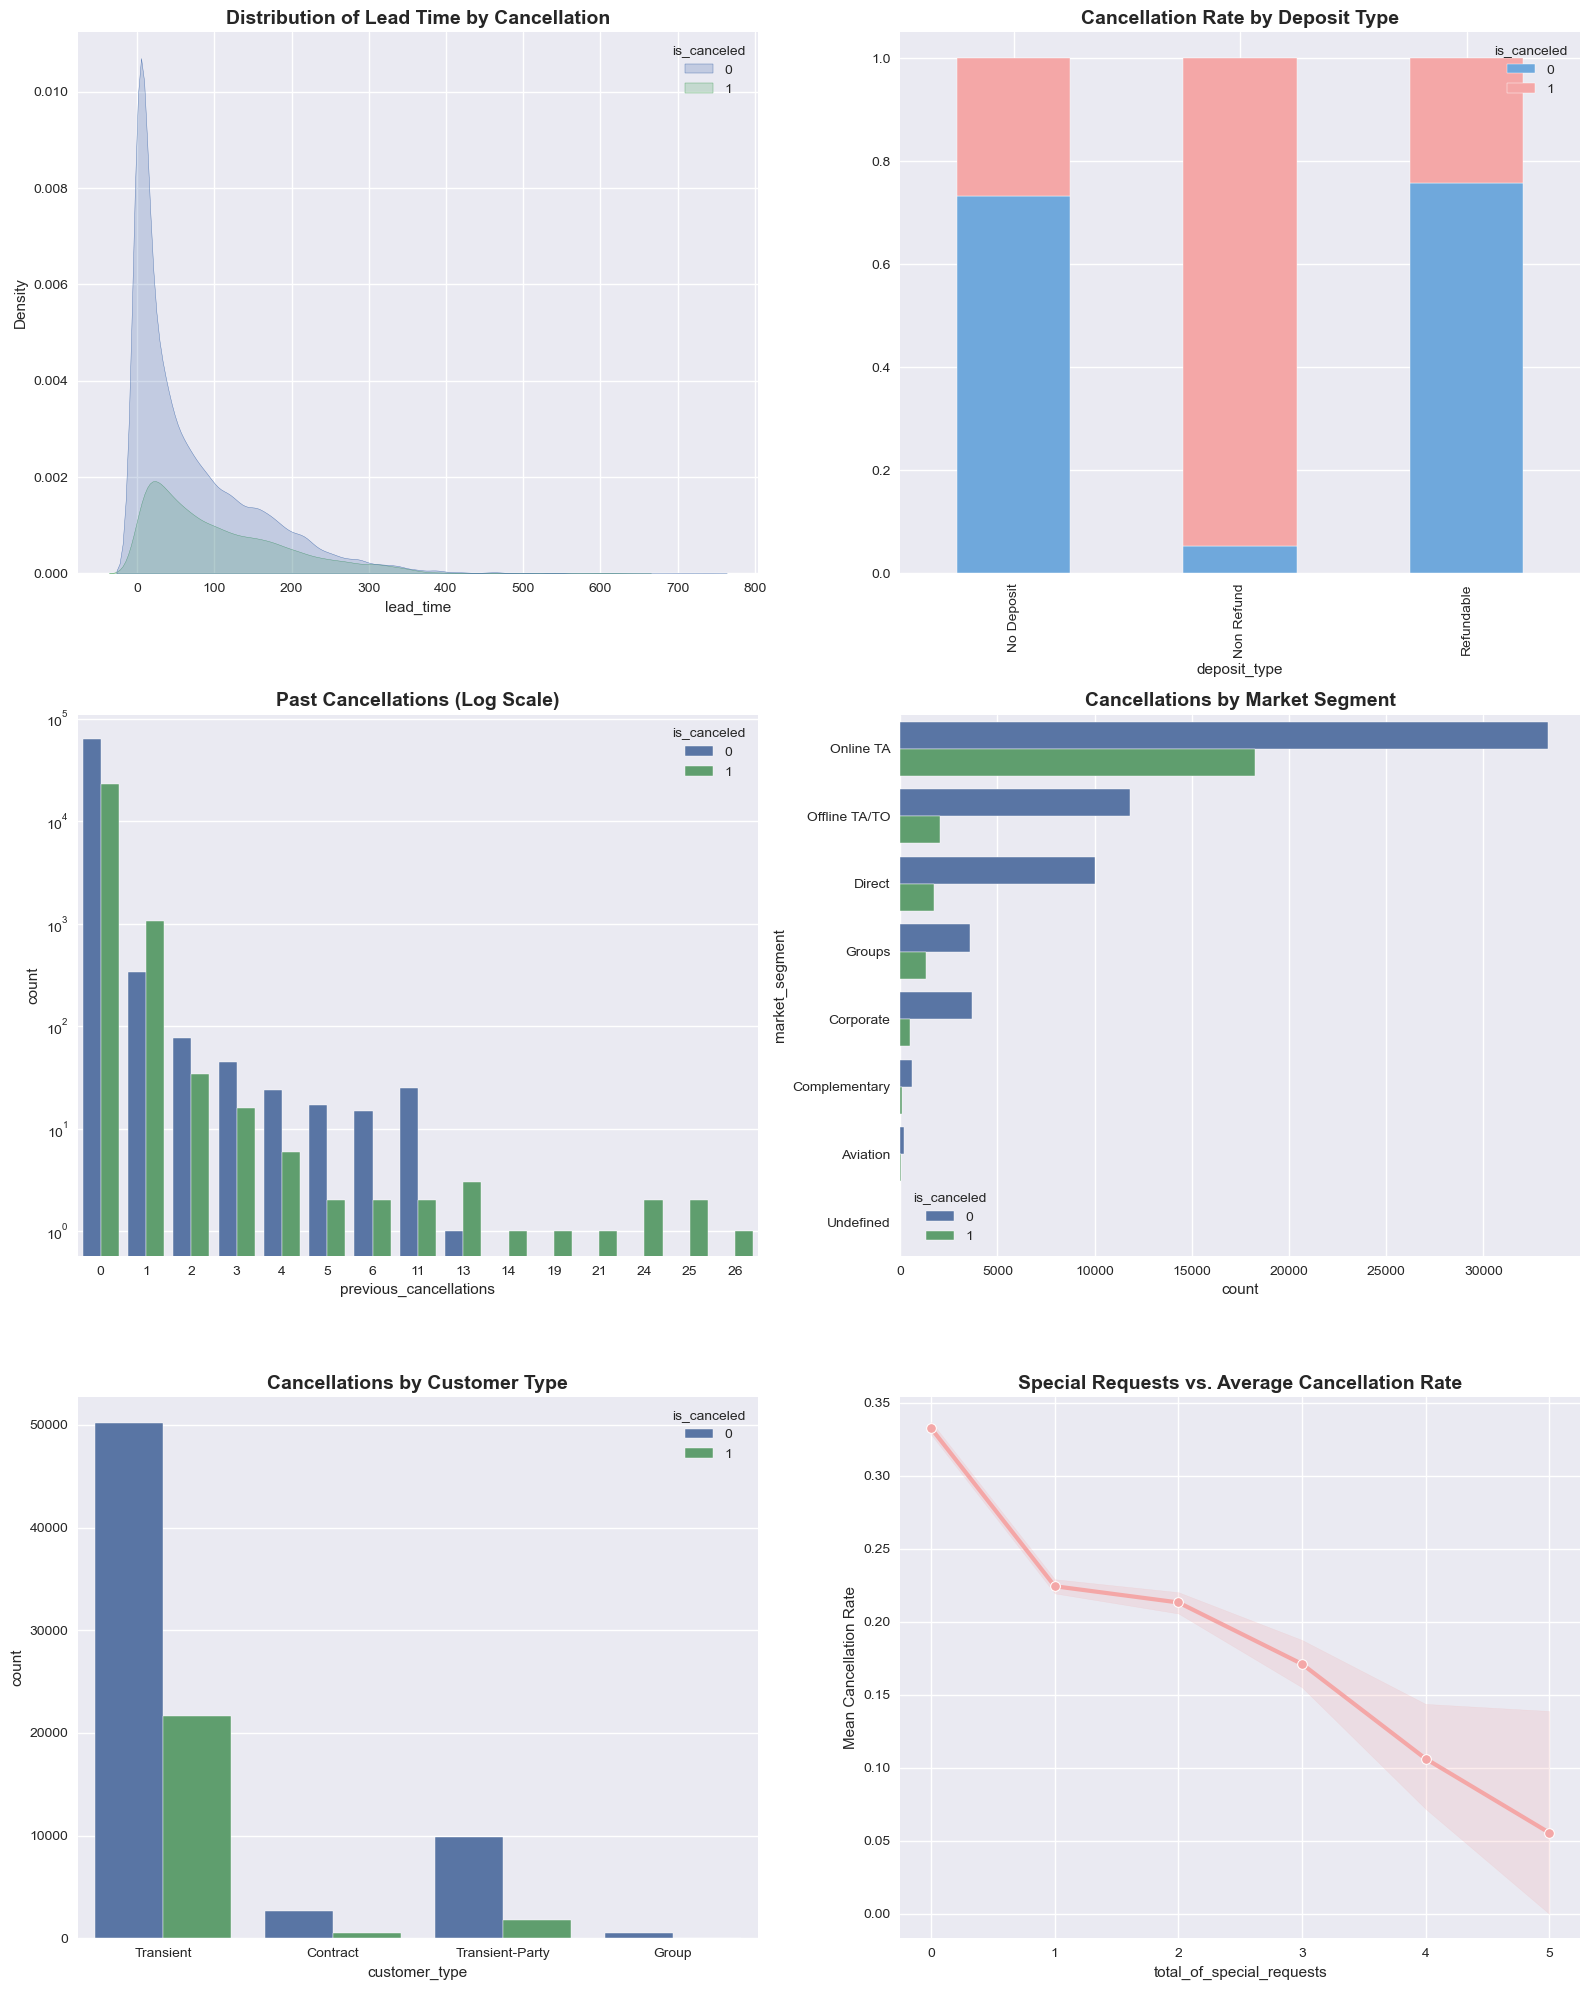

In [ ]:
# Number of booking cancellation vs key features I

# Baseline
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. lead_time (KDE Plot)
sns.kdeplot(data=df, x="lead_time", hue="is_canceled", fill=True, ax=axes[0])
axes[0].set_title("Distribution of Lead Time by Cancellation", fontsize=14, fontweight='bold')

# 2. deposit_type (Normalized Bar Plot)
deposit_cancel = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index')
deposit_cancel.plot(kind='bar', stacked=True, color=['#6FA8DC', '#F4A7A7'], ax=axes[1])
axes[1].set_title("Cancellation Rate by Deposit Type", fontsize=14, fontweight='bold')

# 3. previous_cancellations (Log Scale Count)
sns.countplot(data=df, x="previous_cancellations", hue="is_canceled", ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title("Past Cancellations (Log Scale)", fontsize=14, fontweight='bold')

# 4. market_segment (Horizontal Bar)
order = df[df['is_canceled']==1]['market_segment'].value_counts().index
sns.countplot(data=df, y="market_segment", hue="is_canceled", order=order, ax=axes[3])
axes[3].set_title("Cancellations by Market Segment", fontsize=14, fontweight='bold')

# 5. customer_type (Count Plot)
sns.countplot(data=df, x="customer_type", hue="is_canceled", ax=axes[4])
axes[4].set_title("Cancellations by Customer Type", fontsize=14, fontweight='bold')

# 6. total_of_special_requests (Mean Line Plot)
sns.lineplot(data=df, x="total_of_special_requests", y="is_canceled", marker='o', color='#F4A7A7', linewidth=3, ax=axes[5])
axes[5].set_title("Special Requests vs. Average Cancellation Rate", fontsize=14, fontweight='bold')
axes[5].set_ylabel("Mean Cancellation Rate")

plt.tight_layout()
plt.show()

### Figure 5 — Cancellation Analysis vs Key Features (II)

**Purpose:** Examine how parking requests, ADR, hotel type, booking changes, 
distribution channel, repeated guest status, and past successful bookings relate 
to cancellation behaviour.

**Key Findings:**
- **Parking Request:** Bookings with a parking request exhibit near-zero cancellation rates — the strongest commitment proxy in the dataset → directly motivated **has_parking_request** in Section 3.1
- **ADR:** Higher-priced rooms are associated with greater cancellation risk, suggesting price sensitivity among premium bookings
- **Hotel Type:** City Hotels face notably higher cancellation rates than Resort Hotels, likely reflecting greater urban market competition and travel flexibility → retained **hotel** as a feature rather than building separate models per hotel type
- **Booking Changes:** Guests who modify their booking show lower cancellation propensity, suggesting active engagement signals commitment
- **Distribution Channel:** Direct bookings demonstrate lower cancellation rates than TA/TO channels
- **Repeated Guest:** Returning guests show significantly lower cancellation propensity, confirming loyalty as a strong retention signal → retained as **is_repeated_guest**
- **Past Successful Bookings:** Guests with a history of completed bookings demonstrate lower cancellation risk → retained as **previous_bookings_not_canceled**

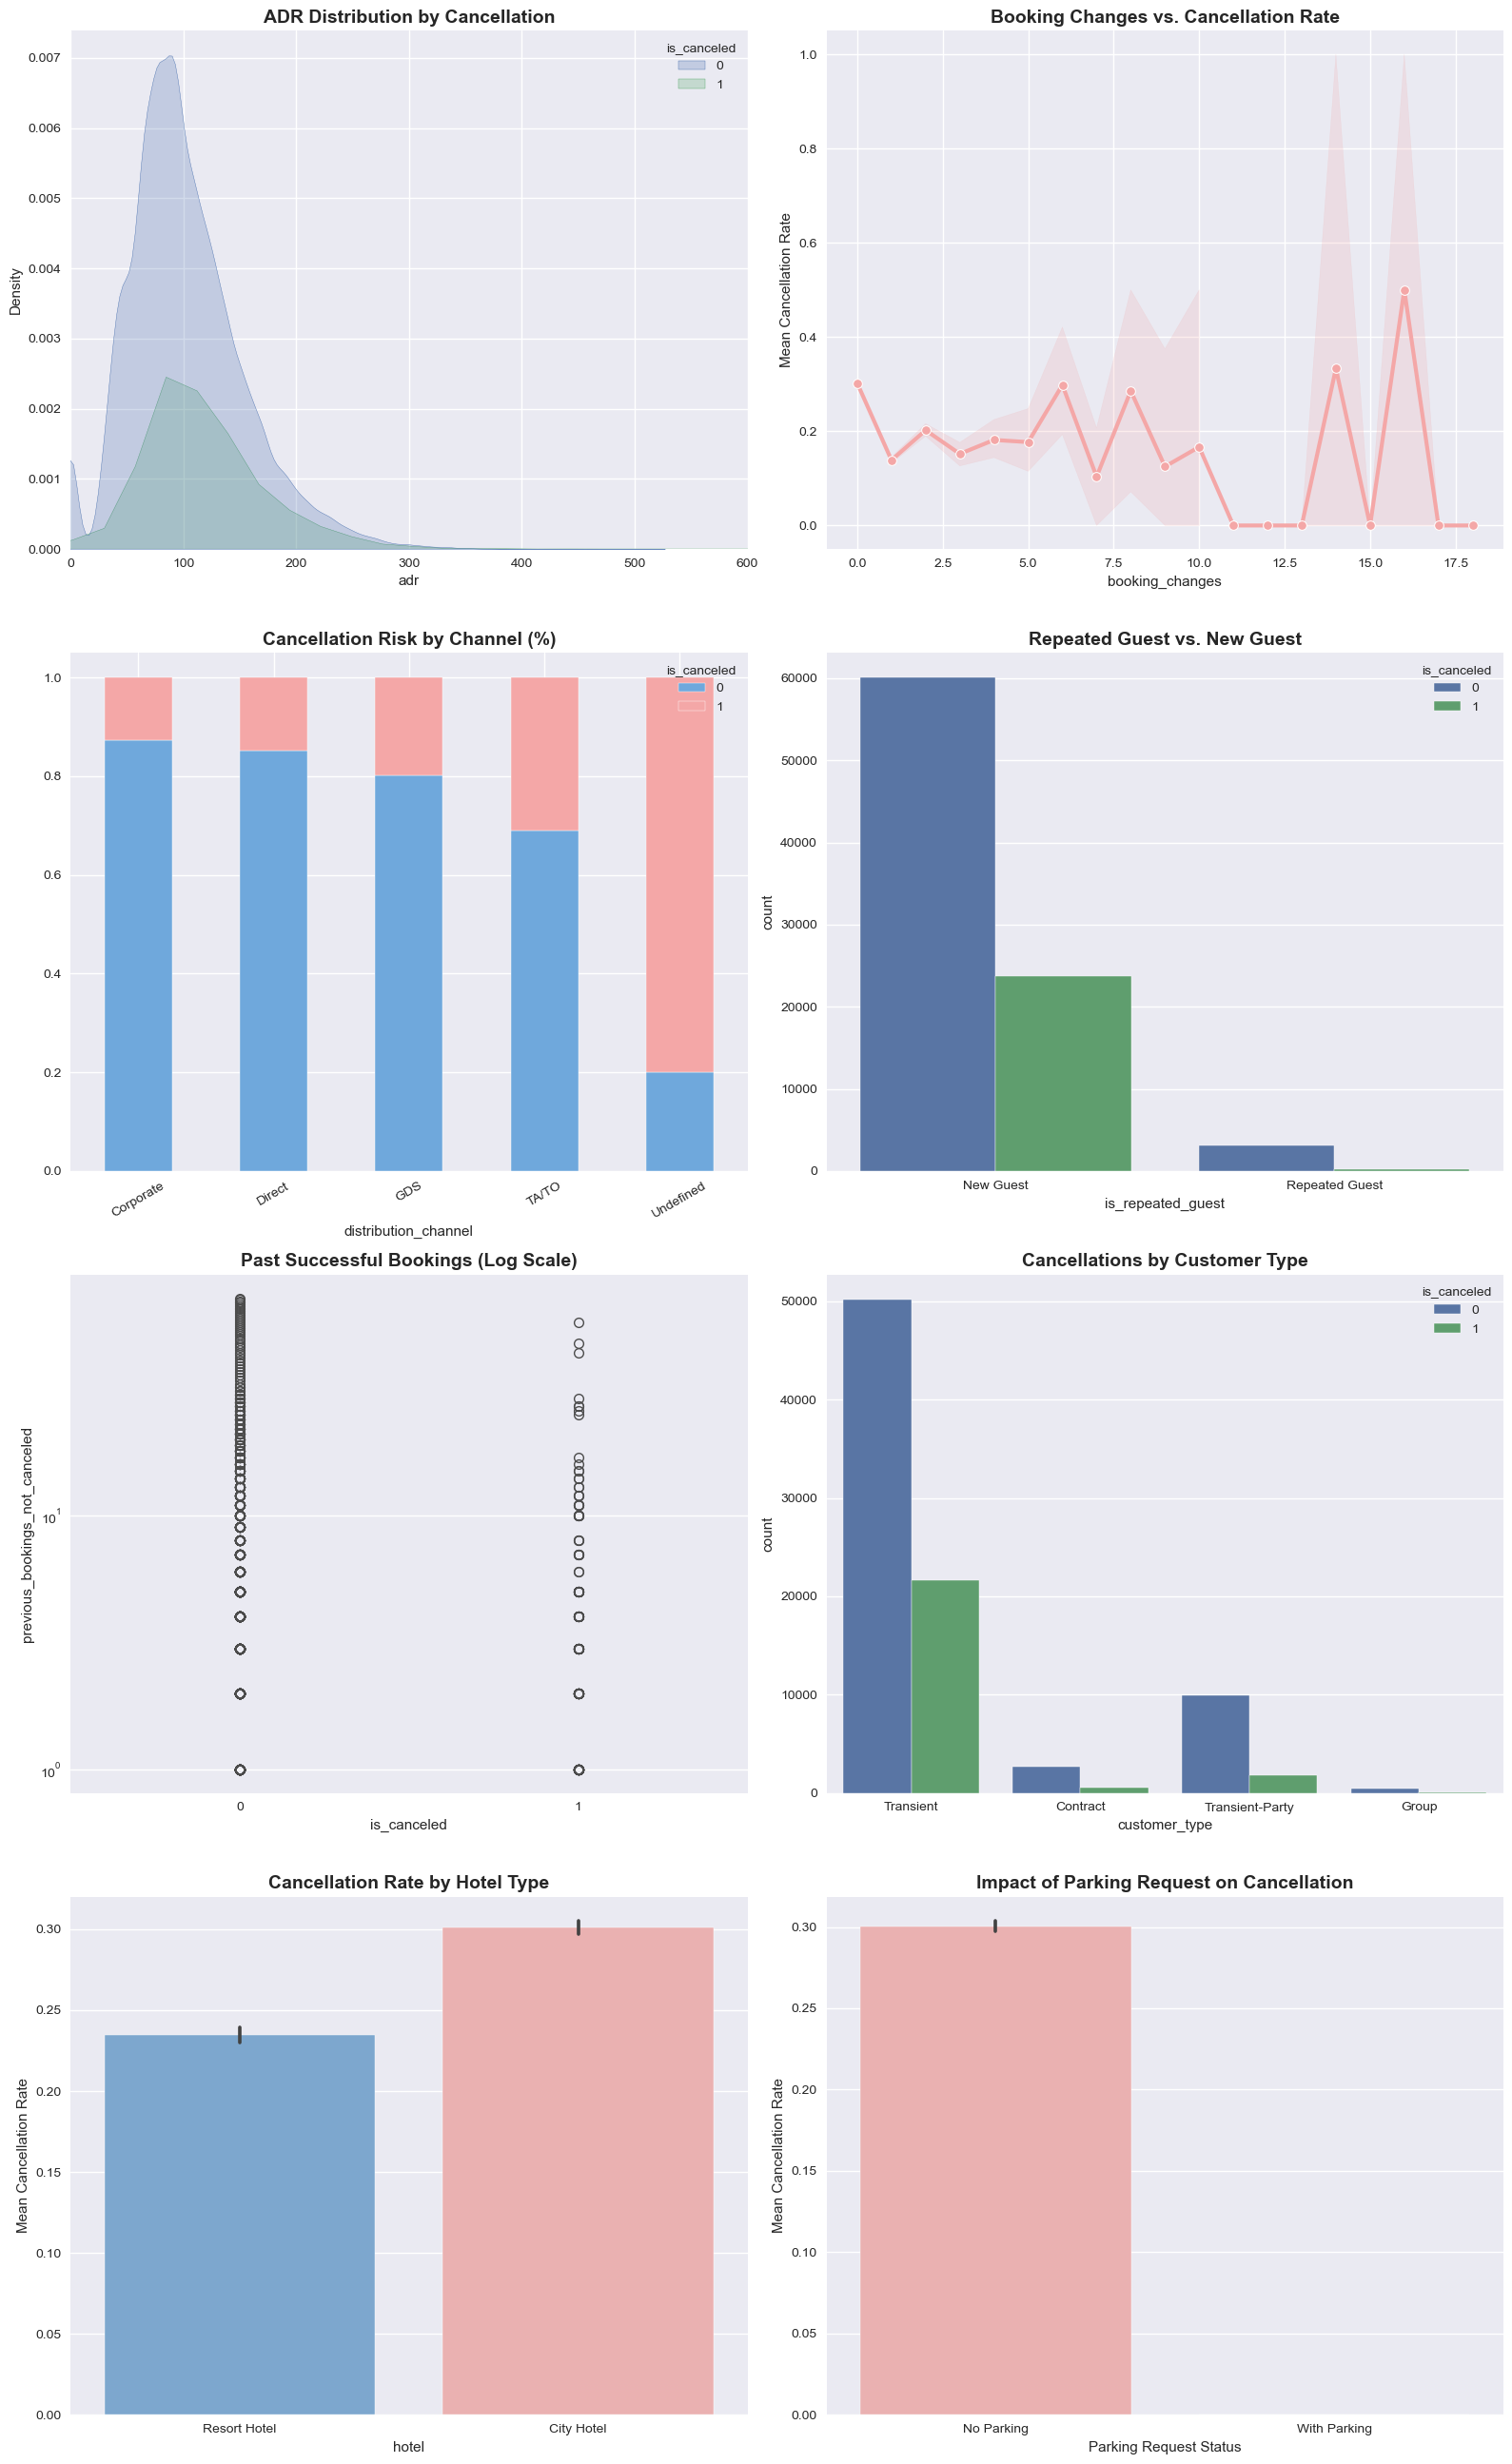

In [ ]:
# Number of booking cancellation vs key features II

# Baseline
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(4, 2, figsize=(16, 26)) 

# 1. adr (KDE Plot)
# Check the cancellation density in different housing price ranges
axes = axes.flatten()
sns.kdeplot(data=df, x="adr", hue="is_canceled", fill=True, ax=axes[0])
axes[0].set_title("ADR Distribution by Cancellation", fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 600)

# 2. booking_changes (Line Plot)
# To confirm that the more changes, the greater the sincerity
sns.lineplot(data=df, x="booking_changes", y="is_canceled", marker='o', color='#F4A7A7', linewidth=3, ax=axes[1])
axes[1].set_title("Booking Changes vs. Cancellation Rate", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Mean Cancellation Rate")

# 3. distribution_channel (Normalized Stacked Bar)
# Identify high-risk channels
channel_cancel = pd.crosstab(df['distribution_channel'], df['is_canceled'], normalize='index')
channel_cancel.plot(kind='bar', stacked=True, color=['#6FA8DC', '#F4A7A7'], ax=axes[2])
axes[2].set_title("Cancellation Risk by Channel (%)", fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

# 4. is_repeated_guest (Count Plot)
# Loyalty Comparison
sns.countplot(data=df, x="is_repeated_guest", hue="is_canceled", ax=axes[3])
axes[3].set_title("Repeated Guest vs. New Guest", fontsize=14, fontweight='bold')
axes[3].set_xticklabels(['New Guest', 'Repeated Guest'])

# 5. previous_bookings_not_canceled (Log-scale Box Plot)
# The impact of a successful record
sns.boxplot(data=df, x="is_canceled", y="previous_bookings_not_canceled", ax=axes[4])
axes[4].set_yscale('log')
axes[4].set_title("Past Successful Bookings (Log Scale)", fontsize=14, fontweight='bold')

# 6. customer_type (Count Plot)
# Category Behavior Analysis
sns.countplot(data=df, x="customer_type", hue="is_canceled", ax=axes[5])
axes[5].set_title("Cancellations by Customer Type", fontsize=14, fontweight='bold')

# 7. hotel (Bar Plot)
# Comparison of restaurant types
sns.barplot(data=df, x="hotel", y="is_canceled", palette=['#6FA8DC', '#F4A7A7'], ax=axes[6])
axes[6].set_title("Cancellation Rate by Hotel Type", fontsize=14, fontweight='bold')
axes[6].set_ylabel("Mean Cancellation Rate")

# 8. required_car_parking_spaces (Bar Plot)
# Show a strong negative correlation between parking space demand and cancellation rate
# Create a new features to differentiate between "parking available" and "no parking available" 
df['has_parking_request'] = df['required_car_parking_spaces'].apply(lambda x: 'With Parking' if x > 0 else 'No Parking')

sns.barplot(data=df, x="has_parking_request", y="is_canceled", 
            palette=['#F4A7A7', '#6FA8DC'], ax=axes[7])

axes[7].set_title("Impact of Parking Request on Cancellation", fontsize=14, fontweight='bold')
axes[7].set_ylabel("Mean Cancellation Rate")
axes[7].set_xlabel("Parking Request Status")

plt.tight_layout()
plt.show()

In [18]:
# Step 1: Consolidating Guest Composition & Staying Behavior

# 1. Consolidate staying behavior (Total Nights)
# Simplifies the model's understanding of "Short-stay" vs "Long-stay" patterns.
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 2. Consolidate guest composition (Total Kids)
# Combine children and babies to categorize "Family" segments.
df['total_kids'] = df['children'] + df['babies']

# 3. Refined ADR per Person (Economic Intensity)
# Divide ADR by total guests. '+ 1' prevents division by zero.
# Rounded to 2 decimal places for financial clarity.
df['adr_per_person'] = (df['adr'] / (df['adults'] + df['total_kids'] + 1)).round(2)

# 4. Defining Guest Type (Binary Family Flag)
# Crucial for the "Family + Parking" interaction analysis.
df['is_family'] = (df['total_kids'] > 0).astype(int)

# Sanity Check & Distribution Summary
print(f"Zero ADR Count: {(df['adr'] == 0).sum()}")
print("\nFeature Distribution Summary")
print(df[['total_stay', 'total_kids', 'adr_per_person', 'is_family']].describe())

Zero ADR Count: 1643

Feature Distribution Summary
         total_stay    total_kids  adr_per_person     is_family
count  87222.000000  87222.000000    87222.000000  87222.000000
mean       3.628672      0.149756       35.385243      0.104366
std        2.742888      0.472151       16.942127      0.305736
min        0.000000      0.000000        0.000000      0.000000
25%        2.000000      0.000000       25.000000      0.000000
50%        3.000000      0.000000       33.330000      0.000000
75%        5.000000      0.000000       43.750000      0.000000
max       69.000000     10.000000     1800.000000      1.000000


In [19]:
# Step 2: Engineering Interaction Features (Family & Risk Segments)

# 1. Statistical Impact of Family & Parking
# Calculate the cancellation rate for our new "Safe Segment"
df['has_kids'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['family_with_parking'] = ((df['has_kids'] == 1) & (df['has_parking_request'] == '1')).astype(int)
family_parking_impact = df.groupby('family_with_parking')['is_canceled'].mean()
print("Cancellation Rate: Family with Parking")
print(family_parking_impact)

# 2. Risk Segmentation Analysis (Channel & Deposit)
# Identify the Top 5 High-Risk combinations created by the interaction
df['channel_deposit_risk'] = df['market_segment'].astype(str) + "_" + df['deposit_type'].astype(str)
risk_segment_stats = df.groupby('channel_deposit_risk')['is_canceled'].mean().sort_values(ascending=False)
print("\nTop 5 Highest Risk Segments")
print(risk_segment_stats.head(5))

# 3. Frequency Count
# Check if the segments have enough data points to be statistically significant
print("\nSegment Sample Sizes")
print(df['channel_deposit_risk'].value_counts().head(5))

Cancellation Rate: Family with Parking
family_with_parking
0    0.275263
Name: is_canceled, dtype: float64

Top 5 Highest Risk Segments
channel_deposit_risk
Undefined_No Deposit        1.000000
Online TA_Refundable        1.000000
Offline TA/TO_Non Refund    0.989547
Groups_Non Refund           0.959029
Online TA_Non Refund        0.833333
Name: is_canceled, dtype: float64

Segment Sample Sizes
channel_deposit_risk
Online TA_No Deposit        51518
Offline TA/TO_No Deposit    13564
Direct_No Deposit           11764
Groups_No Deposit            4182
Corporate_No Deposit         4129
Name: count, dtype: int64


# 3. Feature Engineering

Building on the behavioural patterns identified in EDA, this section transforms 
raw features into a refined set of 14 model-ready inputs. The process is structured 
in two stages:

1. **Feature Creation (Section 3.1)** — engineer six new features capturing higher-level business signals
2. **Feature Pruning & Encoding (Section 3.2)** — reduce 41 columns to 14 via leakage prevention, encoding, and VIF analysis

## 3.1 Feature Creation

Six new features were engineered to capture higher-level business signals identified 
in EDA. Each feature is justified by a specific behavioural pattern observed in Section 2.

---

**1. total_stay**
- **Definition:** stays_in_weekend_nights + stays_in_week_nights
- **Rationale:** Total stay duration is a more meaningful booking signal than weekend/weekday nights separately. Longer stays may indicate stronger commitment.
- **Type:** Numerical

**2. is_family**
- **Definition:** 1 if children > 0 or babies > 0, else 0
- **Rationale:** Family bookings involve more complex logistics (room type, meal plan, activities), suggesting higher switching costs and lower cancellation propensity.
- **Type:** Binary

**3. is_portugal**
- **Definition:** 1 if country == 'PRT', else 0
- **Rationale:** Portuguese guests represent the majority of the dataset and exhibit disproportionately high cancellation rates. Flagging nationality captures this systematic risk pattern.
- **Type:** Binary

**4. is_peak_season**
- **Definition:** 1 if arrival month is June, July, August, or September, else 0
- **Rationale:** EDA (Figure 3) confirmed peak season (32.00% cancellation rate) carries significantly higher cancellation risk than off-peak (26.10%). Binning captures this nonlinear relationship.
- **Type:** Binary

**5. lead_time_group**
- **Definition:** Binned into four groups — Last-minute (0–7 days), Short (8–30 days), Medium (31–180 days), Long (181+ days)
- **Rationale:** EDA (Figure 4) confirmed cancellation risk escalates nonlinearly with lead time, from 8.40% for last-minute to 36.90% for long-term reservations. Raw lead_time would treat this as linear.
- **Type:** Ordinal Categorical

**6. has_parking_request**
- **Definition:** 1 if required_car_parking_spaces > 0, else 0
- **Rationale:** EDA (Figure 5) identified parking requests as the strongest commitment proxy in the dataset, with near-zero cancellation rates. Converting to binary simplifies the signal.
- **Type:** Binary

---

> **Agent Tooling Note:** Claude suggested creating interaction features including 
> family_with_parking and channel_deposit_risk. These were accepted initially but 
> subsequently rejected after VIF analysis revealed critical multicollinearity 
> (VIF > 400), as documented in Section 3.2.

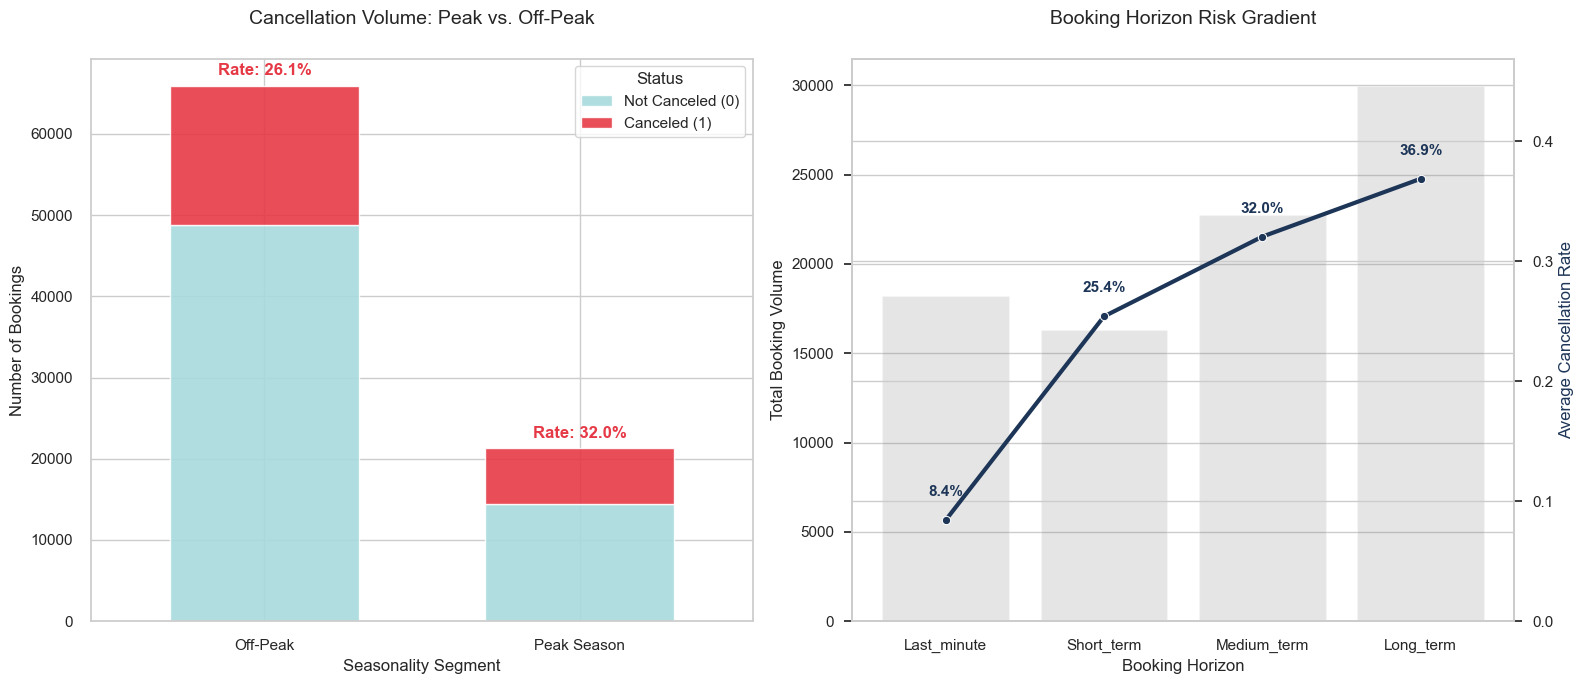

Success: Analysis based on 87,222 total bookings.


In [ ]:
# 3.1 Feature Creation

# Step 3: Feature Engineering - Temporal Transformation

# 1. Feature Engineering: Temporal Transformation
df['arrival_date_month'] = df['arrival_date_month'].astype(str).str.strip().str.lower()
peak_months = ['july', 'august', '7', '8', 'jul', 'aug'] 
df['is_peak_season'] = df['arrival_date_month'].isin(peak_months).astype(int)

bins = [-1, 7, 30, 90, float('inf')]
labels = ['Last_minute', 'Short_term', 'Medium_term', 'Long_term']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

# 2. Visualization: Stacked Bar & Dual-Axis Trend
sns.set_theme(style="whitegrid")
fig, (ax_season, ax_lead) = plt.subplots(1, 2, figsize=(16, 7))

# Seasonality Cancellation Structure
season_stats = df.groupby(['is_peak_season', 'is_canceled']).size().unstack(fill_value=0)
season_stats.index = ['Off-Peak', 'Peak Season']
season_stats.plot(kind='bar', stacked=True, ax=ax_season, color=['#A8DADC', '#E63946'], alpha=0.9, width=0.6)

ax_season.set_title('Cancellation Volume: Peak vs. Off-Peak', fontsize=14, pad=25)
ax_season.set_ylabel('Number of Bookings', fontsize=12)
ax_season.set_xlabel('Seasonality Segment', fontsize=12)
ax_season.legend(['Not Canceled (0)', 'Canceled (1)'], title='Status', frameon=True)
plt.setp(ax_season.get_xticklabels(), rotation=0)

# Display the plots

# Peak vs off-peak months
for i in range(len(season_stats)):
    total = season_stats.iloc[i].sum()
    canceled = season_stats.iloc[i, 1]
    pct = canceled / total
    ax_season.text(i, total + (df.shape[0]*0.01), f'Rate: {pct:.1%}', 
                  ha='center', va='bottom', weight='bold', color='#E63946', fontsize=12)

# Lead Time vs. Cancellation Risk (Dual-Axis Chart)
lt_stats = df.groupby('lead_time_group', observed=False)['is_canceled'].agg(['mean', 'count']).reset_index()

# Bar Chart for Volume
ax_vol = ax_lead
sns.barplot(data=lt_stats, x='lead_time_group', y='count', alpha=0.2, color='gray', ax=ax_vol)
ax_vol.set_ylabel('Total Booking Volume', fontsize=12)
ax_vol.set_xlabel('Booking Horizon', fontsize=12)

# Line Chart for Risk Trend
ax_risk = ax_vol.twinx()
sns.lineplot(data=lt_stats, x='lead_time_group', y='mean', marker='o', ax=ax_risk, color='#1D3557', linewidth=3)
ax_risk.set_ylabel('Average Cancellation Rate', fontsize=12, color='#1D3557')
ax_risk.set_ylim(0, lt_stats['mean'].max() + 0.1) # Dynamic limit for clarity

# Add data labels outside for the trend line
for i, val in enumerate(lt_stats['mean']):
    ax_risk.text(i, val + 0.02, f'{val:.1%}', color='#1D3557', ha='center', weight='bold', fontsize=11)

plt.title('Booking Horizon Risk Gradient', fontsize=14, pad=25)
plt.tight_layout()
plt.show()

print(f"Success: Analysis based on {len(df):,} total bookings.")

## 3.2 Feature Pruning & Encoding

A two-stage pruning process reduced the initial 41 columns to the final 14 model-ready features.

---

**Stage 1: Data Leakage Prevention (41 → 21 features)**

The following posterior variables were removed — fields only known after a booking 
outcome is confirmed and therefore unavailable at prediction time:

| Feature | Reason for Removal |
|---------|-------------------|
| reservation_status | Directly reveals cancellation outcome |
| reservation_status_date | Posterior timestamp of outcome |
| assigned_room_type | Only assigned at check-in |
| arrival_date_year | Temporal leakage risk |
| arrival_date_week_number | Temporal leakage risk |
| arrival_date_day_of_month | Temporal leakage risk |

---

**Stage 2: VIF Analysis (21 → 14 features)**

Variance Inflation Factor (VIF) analysis identified critical multicollinearity 
among remaining features. Features with VIF > 10 were removed:

| Feature | VIF Score | Reason for Removal |
|---------|-----------|-------------------|
| market_segment | 637.30 | Extreme multicollinearity with distribution_channel |
| channel_deposit_risk | 488.62 | Interaction feature causing severe collinearity |
| distribution_channel | High | Redundant with market_segment |
| adr (raw) | High | Replaced by ADR used directly in cost calculation |

All final 14 features achieved VIF scores below 5, providing a stable feature 
set for modelling.

---

**Final 14 Features by Category:**

| Category | Features |
|---------|---------|
| Booking Behaviour & Intent | customer_type, lead_time_group, total_of_special_requests, booking_changes |
| Commitment & Intent Indicators | total_stay, has_parking_request, deposit_type |
| Historical Loyalty & Reputation | previous_bookings_not_canceled, is_repeated_guest, previous_cancellations |
| Contextual & Geographical Drivers | hotel, is_portugal, is_peak_season, is_family |

---

> **Agent Tooling Note:** During model training, Claude omitted the re-encoding step 
> for lead_time_group and has_parking_request after kernel restart, causing a ValueError. 
> Corrected by adding pd.Categorical encoding at the start of the training pipeline.

In [ ]:
# 3.2 Feature Pruning & Encoding

# Step 4: Data Leakage Prevention & Feature Pruning
# 1. Define the "Master Drop List" for pruning
master_drop_list = [
    # Direct Leakage
    'reservation_status', 'reservation_status_date', 'assigned_room_type', 'days_in_waiting_list',
    
    # Redundant Demographics (Simplified by has_kids/is_family)
    'children', 'babies', 'total_kids', 'adults', 'has_kids',
    
    # Multicollinearity (Simplified by total_stay/has_parking_request)
    'stays_in_weekend_nights', 'stays_in_week_nights', 'required_car_parking_spaces',
    
    # Temporal Noise (Simplified by is_peak_season/lead_time_group)
    'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date_week_number',
    
    # High Cardinality Raw Columns
    'agent', 'reserved_room_type', 'meal',
    
    # Raw Lead Time (Already binned into lead_time_group to handle long-tail)
    'lead_time']

# 2. Execute dropping with error handling
df_model_ready = df.drop(columns=[col for col in master_drop_list if col in df.columns], errors='ignore')

# 3. Final Verification
print(f"Pruning Complete")
print(f"Original Columns: {len(df.columns)} | Final Columns: {len(df_model_ready.columns)}")
print("-" * 30)
print("Remaining Features for VIF & Training:")
print(df_model_ready.columns.tolist())

# Check for any remaining Object types that need Encoding
print("\nColumns needing Encoding:")
print(df_model_ready.select_dtypes(include=['object', 'category']).columns.tolist())

Pruning Complete
Original Columns: 41 | Final Columns: 21
------------------------------
Remaining Features for VIF & Training:
['hotel', 'is_canceled', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'customer_type', 'adr', 'total_of_special_requests', 'is_portugal', 'has_parking_request', 'total_stay', 'adr_per_person', 'is_family', 'family_with_parking', 'channel_deposit_risk', 'is_peak_season', 'lead_time_group']

Columns needing Encoding:
['hotel', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'has_parking_request', 'channel_deposit_risk', 'lead_time_group']


In [22]:
# Step 5: Categorical Encoding and Multicollinearity Assessment

# Step 5.1: Categorical Label Encoding
# use Label Encoding to convert text-based categories into integers
# This is a prerequisite for VIF calculation as it requires a purely numerical matrix
df_encoded = df_model_ready.copy()
le = LabelEncoder()

# Identify all remaining qualitative columns (Object & Category) for transformation
categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    # Converting to string first ensures the encoder handles mixed types safely
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Step 5.2: Multicollinearity Check via VIF
# drop the target variable 'is_canceled' to focus solely on feature independence
X_vif = df_encoded.drop(columns=['is_canceled'])

# Initializing a DataFrame to store VIF scores for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns

# Calculate VIF for each feature: VIF = 1 / (1 - R^2)
# High VIF (>5-10) indicates a feature is highly predictable by others (redundant)
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Step 5.3: Output & Review
# Sorting results to highlight potential problematic features at the top
print("VIF Check Results")
print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))

VIF Check Results
                           feature         VIF
0                   market_segment  637.296813
1             channel_deposit_risk  488.618985
2             distribution_channel   37.826065
3                              adr   30.523420
4                   adr_per_person   28.980963
5                    customer_type   16.182112
6                       total_stay    3.191015
7                  lead_time_group    3.165284
8                            hotel    2.005318
9        total_of_special_requests    1.869673
10                     is_portugal    1.750733
11                       is_family    1.745681
12                  is_peak_season    1.609904
13  previous_bookings_not_canceled    1.452446
14               is_repeated_guest    1.423958
15          previous_cancellations    1.205180
16                 booking_changes    1.200661
17             has_parking_request    1.185396
18                    deposit_type    1.084524
19             family_with_parking        

In [23]:
# Step 5.4: Final Pruning to resolve Multicollinearity

# Based on the VIF diagnostic result, removed variables with strong collinearity 
final_vif_drops = [
    'family_with_parking',
    'market_segment',
    'channel_deposit_risk',
    'distribution_channel',
    'adr',
    'adr_per_person',
    'customer_type ' 
]

# Execute final remove
df_final_model = df_encoded.drop(columns=final_vif_drops, errors='ignore')

# Step 5.5: Final VIF Verification
# Validate again to check VIF < 5
X_final = df_final_model.drop(columns=['is_canceled'])
vif_recheck = pd.DataFrame()
vif_recheck["feature"] = X_final.columns
vif_recheck["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(len(X_final.columns))]

print("Final Optimized VIF Results")
print(vif_recheck.sort_values(by="VIF", ascending=False).reset_index(drop=True))

Final Optimized VIF Results
                           feature       VIF
0                    customer_type  4.720022
1                  lead_time_group  2.847927
2                       total_stay  2.800987
3                            hotel  1.912770
4        total_of_special_requests  1.691410
5                      is_portugal  1.645631
6   previous_bookings_not_canceled  1.432185
7                is_repeated_guest  1.371965
8                   is_peak_season  1.367024
9           previous_cancellations  1.203398
10                 booking_changes  1.177025
11             has_parking_request  1.168951
12                       is_family  1.154119
13                    deposit_type  1.046383


## Final 14 Model Input Features

**1. Booking Behaviour & Intent**

- **customer_type** (VIF: 4.72): Differentiates between transient and group booking behaviour
- **lead_time_group** (VIF: 2.85): Captures the nonlinear relationship between advance booking duration and cancellation risk, from 8.40% (last-minute) to 36.90% (long-term)
- **total_of_special_requests** (VIF: 1.69): Guest engagement metric — higher special requests signal stronger booking commitment
- **booking_changes** (VIF: 1.18): Number of times a booking has been modified — active engagement indicates lower cancellation intent

**2. Commitment & Intent Indicators**

- **total_stay** (VIF: 2.80): Total number of nights booked — longer stays suggest higher switching costs
- **has_parking_request** (VIF: 1.17): Strongest commitment proxy in the dataset — guests requesting parking demonstrate near-zero cancellation rates
- **deposit_type** (VIF: 1.05): Differentiates between No Deposit and Non-Refund, directly reflecting the financial cost a guest incurs upon cancellation

**3. Historical Loyalty & Reputation**

- **previous_bookings_not_canceled** (VIF: 1.43): Guest's successful check-in history — stronger track record indicates higher reliability
- **is_repeated_guest** (VIF: 1.37): Repeat customers demonstrate higher loyalty and significantly lower cancellation propensity
- **previous_cancellations** (VIF: 1.20): Captures habitual cancellation behaviour — the strongest historical risk signal

**4. Contextual & Geographical Drivers**

- **hotel** (VIF: 1.91): Differentiates City Hotel vs Resort Hotel — incorporated as a feature rather than building separate models per hotel type
- **is_portugal** (VIF: 1.65): Portuguese guests represent the majority of the dataset and exhibit disproportionately high cancellation rates
- **is_peak_season** (VIF: 1.37): Peak season (June–September) carries 32.00% cancellation rate vs 26.10% off-peak
- **is_family** (VIF: 1.15): Family bookings involve more complex logistics, typically resulting in different cancellation behaviour compared to solo travellers

# 4. Model Selection & Comparison

Three models were selected to cover different machine learning paradigms, each 
justified by specific characteristics of the dataset identified in EDA and 
Feature Engineering:

| Model | Paradigm | Key Strength | Justification |
|-------|----------|-------------|---------------|
| Random Forest | Ensemble (Bagging) | Interpretability, robustness to non-normal distributions | Serves as interpretable baseline; handles skewed features identified in Section 2.2 |
| XGBoost | Ensemble (Boosting) | Proven performance on imbalanced tabular data | scale_pos_weight directly addresses 27.53% class imbalance |
| TabNet | Attention-based Neural Network | Feature selection via attention mechanism | Provides additional explainability layer through sparse attention weights |

All three models were trained on an 80/20 stratified train-test split to preserve 
the 27.53% cancellation ratio across both sets:
- **Train set:** 69,777 records
- **Test set:** 17,445 records

Rather than building separate models per hotel type, hotel is incorporated as a 
feature, allowing the model to learn type-specific cancellation patterns while 
maintaining a unified prediction pipeline applicable across both properties.

## 4.1 Random Forest

**Model Rationale:**
Random Forest was selected as the interpretable baseline model. As an ensemble of 
decision trees using bagging, it handles non-normal distributions and outliers 
robustly without requiring feature scaling — particularly suited to the severely 
skewed features identified in Section 2.2.

**Key Hyperparameters:**
- n_estimators = 100
- max_depth = None (fully grown trees)
- class_weight = None (default, imbalance addressed in Section 5.1)
- random_state = 42

**Results:**

| Metric | Value |
|--------|-------|
| Accuracy | 0.791 |
| ROC-AUC | 0.831 |
| Cancelled Recall | 0.452 |
| Cancelled F1 | 0.543 |

**Key Findings:**
- lead_time_group (importance: 0.203) emerged as the top predictor, consistent with EDA findings
- Cancellation Recall of 0.452 confirms the model correctly identifies less than half of actual cancellations — directly attributable to class imbalance with no compensation mechanism
- High accuracy (0.791) is misleading given the 27.53% cancellation rate — the model defaults toward predicting the majority class
- Weakness directly motivates SMOTE and class weight balancing in Section 5.1

In [29]:
# Convert lead_time_group to numeric if it contains string labels
df['lead_time_group'] = pd.Categorical(df['lead_time_group']).codes
df['has_parking_request'] = pd.Categorical(df['has_parking_request']).codes

FEATURES = [
    'customer_type',
    'lead_time_group',
    'total_of_special_requests',
    'booking_changes',
    'total_stay',
    'has_parking_request',
    'deposit_type',
    'previous_bookings_not_canceled',
    'is_repeated_guest',
    'previous_cancellations',
    'hotel',
    'is_portugal',
    'is_peak_season',
    'is_family'
]

TARGET = 'is_canceled'


Feature matrix shape : (87222, 14)
Cancellation rate    : 27.53%

Train set : 69,777 rows
Test set  : 17,445 rows

Training Random Forest …
Training complete.

  Accuracy  : 0.7911
  ROC-AUC   : 0.8306

Detailed Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.82      0.92      0.86     12643
    Cancelled       0.68      0.45      0.54      4802

     accuracy                           0.79     17445
    macro avg       0.75      0.69      0.70     17445
 weighted avg       0.78      0.79      0.78     17445



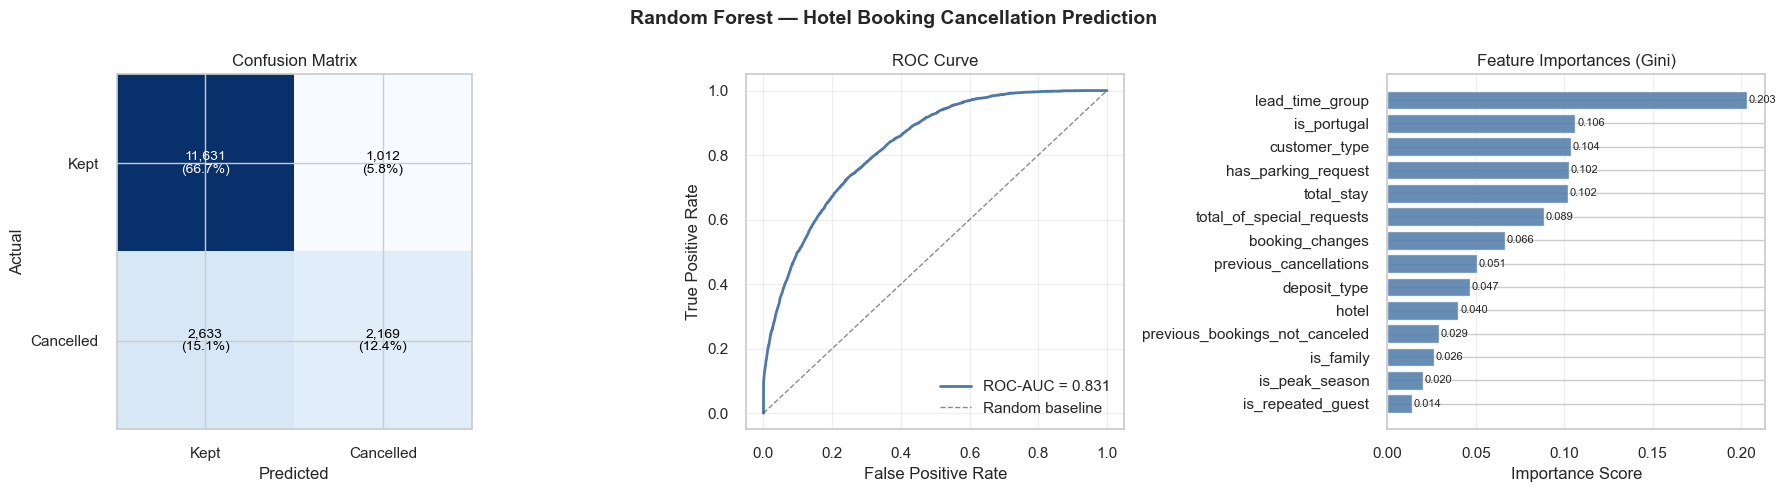


Top Features by Importance (Gini Impurity):
                           Feature  Importance
1                  lead_time_group    0.203429
2                      is_portugal    0.106278
3                    customer_type    0.103587
4              has_parking_request    0.102476
5                       total_stay    0.102266
6        total_of_special_requests    0.088612
7                  booking_changes    0.066341
8           previous_cancellations    0.050548
9                     deposit_type    0.046737
10                           hotel    0.040130
11  previous_bookings_not_canceled    0.029337
12                       is_family    0.026236
13                  is_peak_season    0.020300
14               is_repeated_guest    0.013723


In [30]:
# STEP 1 - ENCODE CATEGORICAL FEATURES
# Random Forest can only handle numeric inputs, so we label-encode the three
# remaining categorical string columns.

le = LabelEncoder()
for col in ['customer_type', 'deposit_type', 'hotel']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df[FEATURES]
y = df[TARGET]

print(f"\nFeature matrix shape : {X.shape}")
print(f"Cancellation rate    : {y.mean():.2%}")


# STEP 2 — TRAIN / TEST SPLIT
# Use stratify=y to preserve the same cancellation ratio in both subsets,
# which is important because the classes are imbalanced (~28% cancellations).

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # fixed seed for reproducibility
    stratify=y,         # maintain class balance in each split
)

print(f"\nTrain set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")


# STEP 3 — TRAIN RANDOM FOREST

# Key hyperparameters:
#   n_estimators = 100  : number of decision trees in the forest
#   max_depth    = 15   : maximum depth of each tree (prevents overfitting)
#   random_state = 42   : ensures reproducibility

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,          # use all available CPU cores for faster training
)

print("\nTraining Random Forest …")
rf.fit(X_train, y_train)
print("Training complete.")


# STEP 4 — EVALUATE MODEL

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]   # probability of cancellation

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print(f"\n{'='*50}")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"{'='*50}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 5 — VISUALISATIONS

# Three plots are generated in a single figure:
#   1. Confusion Matrix  — shows counts and percentages of correct/wrong predictions
#   2. ROC Curve         — illustrates the trade-off between TPR and FPR
#   3. Feature Importances — ranks which features drive the model most

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Hotel Booking Cancellation Prediction',
             fontsize=14, fontweight='bold')

# Display the plots

# Plot 1: Confusion Matrix
# Rows = actual class, Columns = predicted class
# Diagonal cells = correct predictions; off-diagonal = errors
cm    = confusion_matrix(y_test, y_pred)
total = cm.sum()

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Kept', 'Cancelled'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Kept', 'Cancelled'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Annotate each cell with count and percentage of total
for (r, c), v in np.ndenumerate(cm):
    axes[0].text(c, r, f'{v:,}\n({v/total:.1%})',
                 ha='center', va='center',
                 color='white' if v/total > 0.3 else 'black', fontsize=10)

# Plot 2: ROC Curve
# AUC closer to 1.0 = better discrimination between cancelled and kept bookings
# The dashed diagonal represents a random (no-skill) classifier (AUC = 0.5)
fpr, tpr, _ = roc_curve(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#4E79A7', linewidth=2,
             label=f'ROC-AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Feature Importances
# Gini importance: measures how much each feature reduces impurity across all trees
# Higher value = feature is used more often and splits data more effectively
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

axes[2].barh(importances.index, importances.values, color='#4E79A7', alpha=0.85)
axes[2].set_title('Feature Importances (Gini)')
axes[2].set_xlabel('Importance Score')
axes[2].grid(axis='x', alpha=0.3)

# Label each bar with its exact importance value
for i, v in enumerate(importances.values):
    axes[2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()

# Display the plot inline
plt.show()

# STEP 6 — FEATURE IMPORTANCE SUMMARY

importance_df = (
    pd.DataFrame({'Feature': FEATURES, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
importance_df.index += 1  # start ranking from 1

print("\nTop Features by Importance (Gini Impurity):")
print(importance_df.to_string())

### 4.1 Results & Interpretation
- Recall 0.452 confirms model defaults toward majority class without imbalance compensation
- lead_time_group (0.203) as top feature is consistent with EDA findings in Figure 4
- High accuracy (0.791) is misleading — model predicts majority class most of the time
- Directly motivates SMOTE and class weight balancing in Section 5.1

## 4.2 XGBoost

**Model Rationale:**
XGBoost was selected for its proven performance on imbalanced tabular data. As a 
gradient boosting framework, it sequentially corrects errors from previous trees, 
making it particularly effective at identifying minority class patterns. The 
scale_pos_weight parameter directly compensates for the 27.53% class imbalance 
by up-weighting cancellation cases during training.

**Key Hyperparameters:**
- n_estimators = 100
- max_depth = 6
- learning_rate = 0.1
- scale_pos_weight = 2.63 (ratio of non-cancelled to cancelled: 72.47% / 27.53%)
- random_state = 42

**Results:**

| Metric | Value |
|--------|-------|
| Accuracy | 0.718 |
| ROC-AUC | 0.832 |
| Cancelled Recall | 0.779 |
| Cancelled F1 | 0.603 |

**Key Findings:**
- has_parking_request (importance: 0.407) dominated feature importance, consistent with EDA findings in Figure 5
- Highest cancellation Recall (0.779) among all three models — scale_pos_weight successfully compensates for class imbalance
- Highest ROC-AUC (0.832), confirming strongest overall discriminative ability
- Lower accuracy (0.718) reflects the trade-off of prioritising cancellation detection over majority class prediction
- Selected as the primary candidate for hyperparameter tuning in Section 5.1

Training XGBoost …
Training complete.

  Accuracy  : 0.7180
  ROC-AUC   : 0.8323

Detailed Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.89      0.69      0.78     12643
    Cancelled       0.49      0.78      0.60      4802

     accuracy                           0.72     17445
    macro avg       0.69      0.74      0.69     17445
 weighted avg       0.78      0.72      0.73     17445



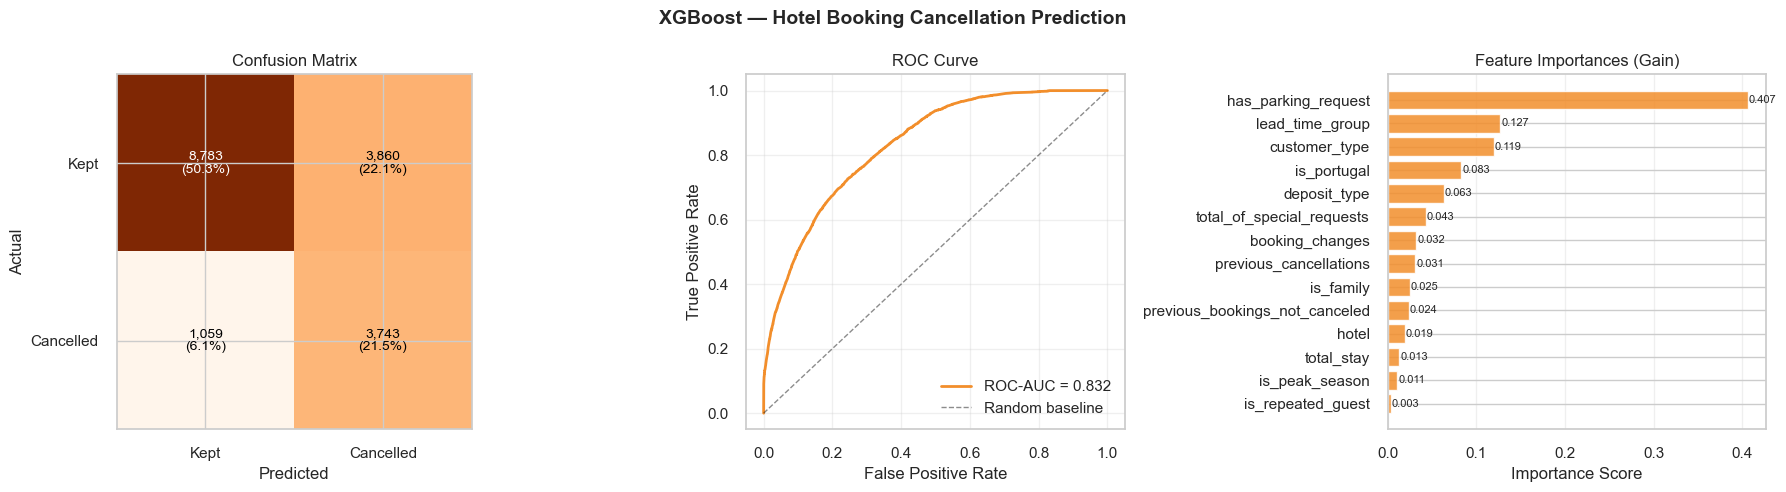


Top Features by Importance (Gain):
                           Feature  Importance
1              has_parking_request    0.406560
2                  lead_time_group    0.126846
3                    customer_type    0.119477
4                      is_portugal    0.082904
5                     deposit_type    0.063045
6        total_of_special_requests    0.042739
7                  booking_changes    0.031968
8           previous_cancellations    0.031251
9                        is_family    0.024983
10  previous_bookings_not_canceled    0.023524
11                           hotel    0.019405
12                      total_stay    0.013207
13                  is_peak_season    0.010803
14               is_repeated_guest    0.003288


In [31]:
# STEP 1 — TRAIN XGBoost

# Key hyperparameters:
#   n_estimators      = 100  : number of boosting rounds (trees)
#   learning_rate     = 0.1  : step size shrinkage to prevent overfitting
#   max_depth         = 6    : maximum depth of each tree
#   scale_pos_weight        : handles class imbalance by weighting the minority
#                             class — set to ratio of negative / positive samples
#   use_label_encoder = False: suppress deprecation warning
#   eval_metric       = logloss: evaluation metric used during training

scale = (y_train == 0).sum() / (y_train == 1).sum()  # ~2.6 (negatives / positives)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale,     # compensate for imbalanced classes
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,                  # use all available CPU cores
)

print("Training XGBoost …")
xgb_model.fit(X_train, y_train)
print("Training complete.")


# STEP 2 — EVALUATE MODEL

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]   # cancellation probability

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print(f"\n{'='*50}")
print(f"  Accuracy  : {accuracy_xgb:.4f}")
print(f"  ROC-AUC   : {roc_auc_xgb:.4f}")
print(f"{'='*50}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 3 — VISUALISATIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost — Hotel Booking Cancellation Prediction',
             fontsize=14, fontweight='bold')

# Display the plots

# Plot 1: Confusion Matrix
# Rows = actual class, Columns = predicted class
# Diagonal cells = correct predictions; off-diagonal = errors
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
total  = cm_xgb.sum()

axes[0].imshow(cm_xgb, cmap='Oranges')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Kept', 'Cancelled'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Kept', 'Cancelled'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Annotate each cell with count and percentage of total
for (r, c), v in np.ndenumerate(cm_xgb):
    axes[0].text(c, r, f'{v:,}\n({v/total:.1%})',
                 ha='center', va='center',
                 color='white' if v/total > 0.3 else 'black', fontsize=10)

# Plot 2: ROC Curve
# AUC closer to 1.0 = better discrimination between cancelled and kept bookings
# The dashed diagonal represents a random (no-skill) classifier (AUC = 0.5)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[1].plot(fpr_xgb, tpr_xgb, color='#F28E2B', linewidth=2,
             label=f'ROC-AUC = {roc_auc_xgb:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Feature Importances
# XGBoost uses 'gain' by default — measures the average improvement in accuracy
# brought by a feature when it is used in a tree split
importances_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

axes[2].barh(importances_xgb.index, importances_xgb.values, color='#F28E2B', alpha=0.85)
axes[2].set_title('Feature Importances (Gain)')
axes[2].set_xlabel('Importance Score')
axes[2].grid(axis='x', alpha=0.3)

# Label each bar with its exact importance value
for i, v in enumerate(importances_xgb.values):
    axes[2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


# STEP 4 — FEATURE IMPORTANCE SUMMARY

importance_xgb_df = (
    pd.DataFrame({'Feature': FEATURES, 'Importance': xgb_model.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
importance_xgb_df.index += 1  # start ranking from 1

print("\nTop Features by Importance (Gain):")
print(importance_xgb_df.to_string())

### 4.2 Results & Interpretation
- Highest Recall (0.779) confirms scale_pos_weight successfully compensates for imbalance
- has_parking_request dominates importance (0.407) — consistent with EDA Figure 5
- Lower accuracy (0.718) reflects deliberate trade-off: prioritising cancellation detection
- Selected as primary candidate for hyperparameter tuning in Section 5.1

## 4.3 TabNet

**Model Rationale:**
TabNet was selected for its attention-based feature selection mechanism, providing 
an additional layer of explainability beyond traditional tree-based models. Unlike 
Random Forest and XGBoost, TabNet learns which features to attend to at each 
decision step, producing sparse attention weights that highlight the most influential 
predictors for each individual prediction.

**Key Hyperparameters:**
- n_d = n_a = 64 (embedding dimensions)
- n_steps = 5 (number of sequential attention steps)
- gamma = 1.5 (feature reusage regularisation)
- max_epochs = 100
- patience = 20 (early stopping)
- Feature scaling required — StandardScaler applied before training

**Results:**

| Metric | Value |
|--------|-------|
| Accuracy | 0.788 |
| ROC-AUC | 0.828 |
| Cancelled Recall | 0.448 |
| Cancelled F1 | 0.540 |

**Key Findings:**
- has_parking_request (importance: 0.194) also emerged as top predictor, consistent with XGBoost findings
- Feature importance distributed more evenly across predictors compared to XGBoost, reflecting the attention mechanism's ability to utilise multiple features simultaneously
- Cancellation Recall (0.448) similar to Random Forest, confirming both models struggle with class imbalance without compensation
- ROC-AUC (0.828) comparable to Random Forest and XGBoost, confirming all three models have similar discriminative ability at baseline
- Requires significantly longer training time than Random Forest and XGBoost due to neural network architecture

Training TabNet …
Stop training because you reached max_epochs = 100 with best_epoch = 90 and best_val_0_auc = 0.82804
Training complete.

  Accuracy  : 0.7882
  ROC-AUC   : 0.8280

Detailed Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.81      0.92      0.86     12643
    Cancelled       0.67      0.45      0.54      4802

     accuracy                           0.79     17445
    macro avg       0.74      0.68      0.70     17445
 weighted avg       0.78      0.79      0.77     17445



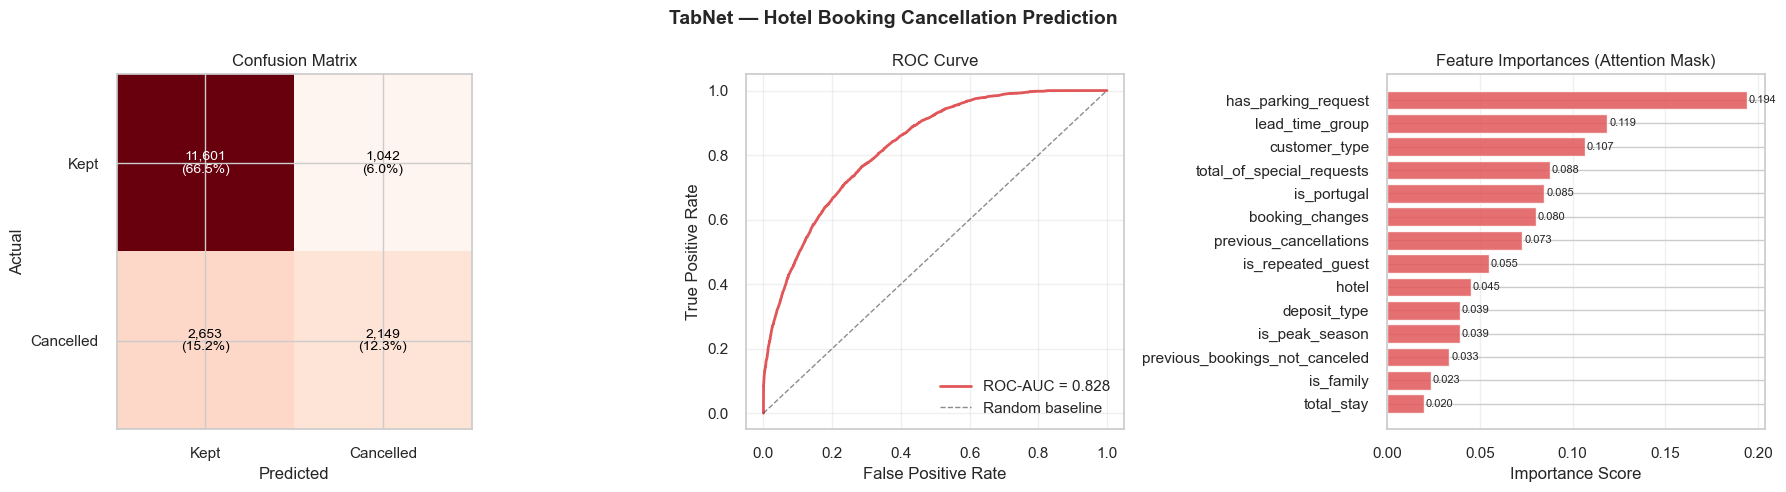


Top Features by Importance (Attention Mask):
                           Feature  Importance
1              has_parking_request    0.194209
2                  lead_time_group    0.118841
3                    customer_type    0.106672
4        total_of_special_requests    0.087758
5                      is_portugal    0.084720
6                  booking_changes    0.080293
7           previous_cancellations    0.072922
8                is_repeated_guest    0.054791
9                            hotel    0.045092
10                    deposit_type    0.039089
11                  is_peak_season    0.039017
12  previous_bookings_not_canceled    0.033424
13                       is_family    0.023340
14                      total_stay    0.019832


In [32]:
# STEP 1 — SCALE FEATURES
# TabNet is a neural network — it requires standardised input (mean=0, std=1)
# fit the scaler on training data only to avoid data leakage

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)        # transform only on test

# TabNet requires numpy arrays with float32 dtype
X_train_tab = X_train_sc.astype('float32')
X_test_tab  = X_test_sc.astype('float32')
y_train_tab = y_train.values                 # convert pandas Series to numpy array
y_test_tab  = y_test.values


# STEP 2 — TRAIN TabNet

# Key hyperparameters:
#   n_d, n_a       = 32   : width of the decision step and attention embedding
#                           larger values = more expressive but slower to train
#   n_steps        = 5    : number of sequential attention steps
#                           more steps = model looks at more feature subsets
#   gamma          = 1.5  : coefficient for feature reusage across steps
#                           higher = features reused more across steps
#   n_independent,
#   n_shared       = 2    : number of independent/shared GLU layers per step
#   momentum       = 0.02 : momentum for batch normalisation
#   mask_type      = 'entmax': sparse attention mask (alternative: 'sparsemax')

tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),   # learning rate for Adam optimiser
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),  # decay LR every 10 epochs
    verbose=0,            # set to 1 to see training progress per epoch
    seed=42,
)

print("Training TabNet …")
tabnet_model.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],   # monitor validation performance
    eval_metric=['auc'],                   # track AUC on validation set
    max_epochs=100,                        # maximum number of training epochs
    patience=20,                           # stop early if no improvement for 20 epochs
    batch_size=1024,                       # number of samples per gradient update
    virtual_batch_size=128,               # sub-batch size for Ghost Batch Normalisation
    drop_last=False,
)
print("Training complete.")

# STEP 3 — EVALUATE MODEL

y_pred_tab = tabnet_model.predict(X_test_tab)
y_prob_tab = tabnet_model.predict_proba(X_test_tab)[:, 1]   # cancellation probability

accuracy_tab = accuracy_score(y_test_tab, y_pred_tab)
roc_auc_tab  = roc_auc_score(y_test_tab, y_prob_tab)

print(f"\n{'='*50}")
print(f"  Accuracy  : {accuracy_tab:.4f}")
print(f"  ROC-AUC   : {roc_auc_tab:.4f}")
print(f"{'='*50}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_tab, y_pred_tab,
                             target_names=['Not Cancelled', 'Cancelled']))

# STEP 4 — VISUALISATIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TabNet — Hotel Booking Cancellation Prediction',
             fontsize=14, fontweight='bold')
# Display the plots

# Plot 1: Confusion Matrix
# Rows = actual class, Columns = predicted class
# Diagonal cells = correct predictions; off-diagonal = errors
cm_tab = confusion_matrix(y_test_tab, y_pred_tab)
total  = cm_tab.sum()

axes[0].imshow(cm_tab, cmap='Reds')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Kept', 'Cancelled'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Kept', 'Cancelled'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Annotate each cell with count and percentage of total
for (r, c), v in np.ndenumerate(cm_tab):
    axes[0].text(c, r, f'{v:,}\n({v/total:.1%})',
                 ha='center', va='center',
                 color='white' if v/total > 0.3 else 'black', fontsize=10)

# Plot 2: ROC Curve
# AUC closer to 1.0 = better discrimination between cancelled and kept bookings
fpr_tab, tpr_tab, _ = roc_curve(y_test_tab, y_prob_tab)

axes[1].plot(fpr_tab, tpr_tab, color='#E15759', linewidth=2,
             label=f'ROC-AUC = {roc_auc_tab:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Feature Importances (Attention Weights)
# TabNet's feature importance is derived from the attention masks across all steps
# Higher value = feature was selected more often during the sequential attention process
feat_importance_tab = pd.Series(
    tabnet_model.feature_importances_, index=FEATURES
).sort_values()

axes[2].barh(feat_importance_tab.index, feat_importance_tab.values,
             color='#E15759', alpha=0.85)
axes[2].set_title('Feature Importances (Attention Mask)')
axes[2].set_xlabel('Importance Score')
axes[2].grid(axis='x', alpha=0.3)

# Label each bar with its exact importance value
for i, v in enumerate(feat_importance_tab.values):
    axes[2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


# STEP 5 — FEATURE IMPORTANCE SUMMARY

importance_tab_df = (
    pd.DataFrame({'Feature': FEATURES,
                  'Importance': tabnet_model.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
importance_tab_df.index += 1  # start ranking from 1

print("\nTop Features by Importance (Attention Mask):")
print(importance_tab_df.to_string())

### 4.3 Results & Interpretation
- Recall (0.448) similar to Random Forest — no imbalance compensation mechanism
- Feature importance more evenly distributed than XGBoost, reflecting attention mechanism
- Comparable ROC-AUC (0.828) confirms similar discriminative ability at baseline
- Significantly longer training time than RF and XGBoost

## 4.4 Model Comparison

All three models were evaluated on the same test set (n = 17,445) using four metrics 
aligned with the success criteria defined in Section 1.2.

| Model | Accuracy | ROC-AUC | Cancelled Recall | Cancelled F1 |
|-------|----------|---------|-----------------|--------------|
| Random Forest | 0.791 | 0.831 | 0.452 | 0.543 |
| XGBoost | 0.718 | 0.832 | 0.779 | 0.603 |
| TabNet | 0.788 | 0.828 | 0.448 | 0.540 |

**Summary:**
- **XGBoost** achieves the highest Recall (0.779) and ROC-AUC (0.832), making it the strongest candidate for further optimisation
- **Random Forest** and **TabNet** share similar weaknesses — low Recall attributable to the absence of a class imbalance compensation mechanism
- All three models achieve comparable ROC-AUC (~0.83), confirming similar underlying discriminative ability regardless of paradigm
- The performance gap between XGBoost Recall (0.779) and RF/TabNet (~0.45) is entirely attributable to scale_pos_weight — directly motivating SMOTE and class weight balancing in Section 5.1

**Two shared weaknesses identified:**
1. Low cancellation Recall in Random Forest and TabNet → addressed by SMOTE and class weight balancing (Section 5.1)
2. Class imbalance sensitivity across all three models → addressed through threshold tuning (Section 5.1)

These weaknesses directly motivate the fine-tuning strategy in Section 5.

# 5. Fine-tuning & Error Analysis

## 5.1 Fine-tuning

The fine-tuning strategy was structured in two phases:

- **Phase 1 (Steps 1–3):** Applied sequentially to address class imbalance and optimise the XGBoost model selected in Section 4
- **Phase 2 (Steps 4–6):** Introduced after error analysis in Section 5.2, targeting specific failure modes rather than global performance

| Step | Method | Phase | Target Weakness |
|------|--------|-------|----------------|
| 1 | SMOTE | Phase 1 | Low Recall in RF and TabNet |
| 2 | XGBoost Hyperparameter Tuning | Phase 1 | Suboptimal F1 and AUC |
| 3 | Threshold Tuning | Phase 1 | Default threshold not optimised |
| 4 | Class Weight Balancing (RF) | Phase 2 *(post error analysis)* | Lightweight SMOTE alternative |
| 5 | No Deposit Sub-Model | Phase 2 *(post error analysis)* | Weakest segment (98% test set) |
| 6 | Ensemble Voting Classifier | Phase 2 *(post error analysis)* | 11.10% misclassified by all models |

---

> **Agent Tooling Note:** Claude suggested the initial hyperparameter search space 
> for RandomizedSearchCV and recommended scale_pos_weight as the primary mechanism 
> for addressing class imbalance in XGBoost. Both suggestions were verified 
> experimentally — scale_pos_weight validated by Recall improvement (0.452→0.779), 
> hyperparameter search space confirmed through 250-fit cross-validation.

### Step 1 — SMOTE (Class Imbalance Handling)

**Purpose:** Balance the training set from 27.53% to 50.00% by generating synthetic 
minority samples to improve Recall across all three models.

**Method:** SMOTE applied to training set only — test set remains untouched to 
preserve evaluation integrity.

**Results:**

| Model | Recall Before | Recall After | Change |
|-------|-------------|-------------|--------|
| Random Forest | 0.452 | 0.761 | +0.309 |
| XGBoost | 0.779 | 0.786 | +0.007 |
| TabNet | 0.448 | 0.760 | +0.312 |

**Key Finding:** ROC-AUC remained virtually unchanged across all three models, 
confirming SMOTE shifts the decision boundary without improving the model's 
underlying discriminative ability. XGBoost shows minimal improvement as 
scale_pos_weight already compensates for class imbalance.

Before SMOTE:
  Not Cancelled : 50,570
  Cancelled     : 19,207
  Ratio         : 27.53%

After SMOTE:
  Not Cancelled : 50,570
  Cancelled     : 50,570
  Ratio         : 50.00%

Training Random Forest with SMOTE …
  ✓ Done
Training XGBoost with SMOTE …
  ✓ Done
Training TabNet with SMOTE …

Early stopping occurred at epoch 98 with best_epoch = 78 and best_val_0_auc = 0.82919
  ✓ Done

── Results with SMOTE ──

  Random Forest + SMOTE
  Accuracy : 0.7270
  ROC-AUC  : 0.8290
               precision    recall  f1-score   support

Not Cancelled       0.89      0.71      0.79     12643
    Cancelled       0.50      0.76      0.61      4802

     accuracy                           0.73     17445
    macro avg       0.69      0.74      0.70     17445
 weighted avg       0.78      0.73      0.74     17445


  XGBoost + SMOTE
  Accuracy : 0.7175
  ROC-AUC  : 0.8308
               precision    recall  f1-score   support

Not Cancelled       0.89      0.69      0.78     12643
    Cancelled     

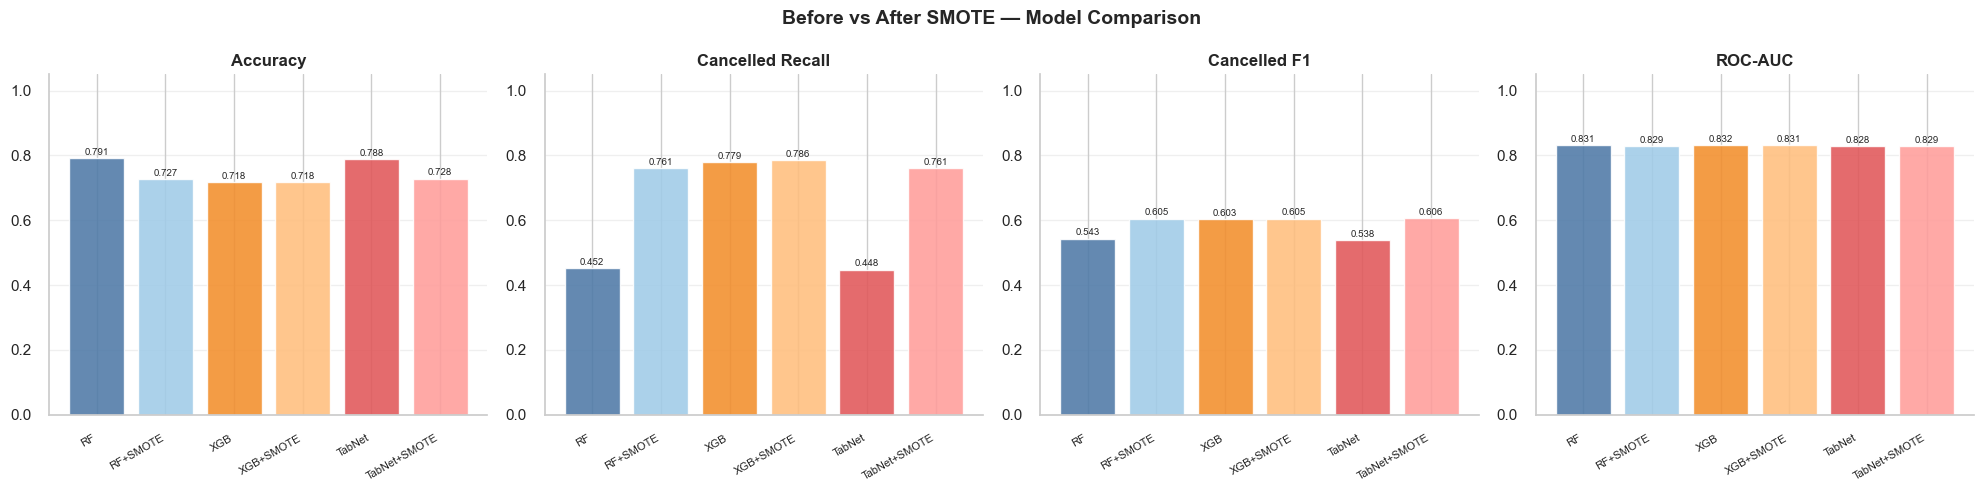


SMOTE comparison complete ✓


In [33]:
# PART A — Fine-tuning: Step 1 — Handle Class Imbalance with SMOTE

# SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples
# for the minority class (Cancelled) to balance the training set.
# Note: SMOTE is applied to training data ONLY to avoid data leakage.


# STEP 1 — APPLY SMOTE TO TRAINING SET

print("Before SMOTE:")
print(f"  Not Cancelled : {(y_train == 0).sum():,}")
print(f"  Cancelled     : {(y_train == 1).sum():,}")
print(f"  Ratio         : {(y_train == 1).sum() / len(y_train):.2%}\n")

# Apply SMOTE — random_state ensures reproducibility
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Not Cancelled : {(y_train_sm == 0).sum():,}")
print(f"  Cancelled     : {(y_train_sm == 1).sum():,}")
print(f"  Ratio         : {(y_train_sm == 1).sum() / len(y_train_sm):.2%}\n")

# STEP 2 — RETRAIN ALL THREE MODELS ON SMOTE DATA

# Random Forest 
print("Training Random Forest with SMOTE …")
rf_sm = RandomForestClassifier(n_estimators=100, max_depth=15,
                                random_state=42, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
print("  ✓ Done")

# XGBoost
# Note: scale_pos_weight is removed since SMOTE already balances the classes
print("Training XGBoost with SMOTE …")
xgb_sm = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1,
)
xgb_sm.fit(X_train_sm, y_train_sm)
print("  ✓ Done")

# TabNet
# TabNet requires scaled float32 arrays — apply same scaler fitted earlier
print("Training TabNet with SMOTE …")
X_train_sm_sc  = scaler.transform(X_train_sm).astype('float32')
y_train_sm_arr = y_train_sm.values

tabnet_sm = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.5,
    n_independent=2, n_shared=2, momentum=0.02,
    mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),
    verbose=0, seed=42,
)
tabnet_sm.fit(
    X_train_sm_sc, y_train_sm_arr,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_metric=['auc'],
    max_epochs=100, patience=20,
    batch_size=1024, virtual_batch_size=128,
    drop_last=False,
)
print("  ✓ Done\n")

# STEP 3 — EVALUATE SMOTE MODELS

def evaluate(name, model, X, y, is_tabnet=False):
    """Return predictions and print classification report."""
    if is_tabnet:
        y_pred = model.predict(X.astype('float32'))
        y_prob = model.predict_proba(X.astype('float32'))[:, 1]
    else:
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy : {accuracy_score(y, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y, y_prob):.4f}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred,
                                 target_names=['Not Cancelled', 'Cancelled']))
    return y_pred, y_prob

print("── Results with SMOTE ──")
rf_sm_pred,     rf_sm_prob     = evaluate("Random Forest + SMOTE", rf_sm, X_test, y_test)
xgb_sm_pred,    xgb_sm_prob    = evaluate("XGBoost + SMOTE",       xgb_sm, X_test, y_test)
tabnet_sm_pred, tabnet_sm_prob = evaluate("TabNet + SMOTE",        tabnet_sm,
                                           X_test_sc, y_test, is_tabnet=True)


# STEP 4 — BEFORE vs AFTER SMOTE COMPARISON CHART
# Compare key metrics (Accuracy, Recall for Cancelled, F1 for Cancelled, AUC)
# between original models and SMOTE-retrained models side by side.

metrics_data = {
    'Model': ['RF', 'RF+SMOTE', 'XGB', 'XGB+SMOTE', 'TabNet', 'TabNet+SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_sm_pred),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, xgb_sm_pred),
        accuracy_score(y_test_tab, y_pred_tab),
        accuracy_score(y_test, tabnet_sm_pred),
    ],
    'Cancelled Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_sm_pred),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, xgb_sm_pred),
        recall_score(y_test_tab, y_pred_tab),
        recall_score(y_test, tabnet_sm_pred),
    ],
    'Cancelled F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_sm_pred),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, xgb_sm_pred),
        f1_score(y_test_tab, y_pred_tab),
        f1_score(y_test, tabnet_sm_pred),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_sm_prob),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, xgb_sm_prob),
        roc_auc_score(y_test_tab, y_prob_tab),
        roc_auc_score(y_test, tabnet_sm_prob),
    ],
}

df_metrics = pd.DataFrame(metrics_data)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Before vs After SMOTE — Model Comparison', fontsize=14, fontweight='bold')

metric_cols  = ['Accuracy', 'Cancelled Recall', 'Cancelled F1', 'ROC-AUC']
bar_colors   = ['#4E79A7', '#A0CBE8',   # RF: dark/light blue
                '#F28E2B', '#FFBE7D',   # XGB: dark/light orange
                '#E15759', '#FF9D9A']   # TabNet: dark/light red

for ax, metric in zip(axes, metric_cols):
    bars = ax.bar(df_metrics['Model'], df_metrics[metric],
                  color=bar_colors, alpha=0.88, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(df_metrics['Model'], rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, df_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print("\nSMOTE comparison complete ✓")

### Step 2 — XGBoost Hyperparameter Tuning

**Purpose:** Identify the optimal XGBoost configuration to improve F1 and ROC-AUC 
beyond the baseline achieved in Section 4.

**Method:** RandomizedSearchCV with 50 iterations × 5-fold stratified CV = 250 fits.
Applied exclusively to XGBoost as it demonstrated the strongest baseline performance 
(highest Recall, F1, and ROC-AUC in Section 4).

**Search Space:**

| Hyperparameter | Range |
|---------------|-------|
| n_estimators | 100–500 |
| max_depth | 3–10 |
| learning_rate | 0.01–0.3 |
| subsample | 0.6–1.0 |
| colsample_bytree | 0.6–1.0 |
| min_

Running RandomizedSearchCV (50 iterations × 5 folds = 250 fits) …
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Search complete.

Best Parameters:
  colsample_bytree     : 0.6431565707973218
  learning_rate        : 0.019428755706020276
  max_depth            : 9
  n_estimators         : 340
  scale_pos_weight     : 2.2574239243053067
  subsample            : 0.8034282764658811

Best CV ROC-AUC : 0.8275

  XGBoost Tuned
  Accuracy : 0.7455
  ROC-AUC  : 0.8331
               precision    recall  f1-score   support

Not Cancelled       0.88      0.75      0.81     12643
    Cancelled       0.53      0.74      0.61      4802

     accuracy                           0.75     17445
    macro avg       0.70      0.74      0.71     17445
 weighted avg       0.78      0.75      0.76     17445



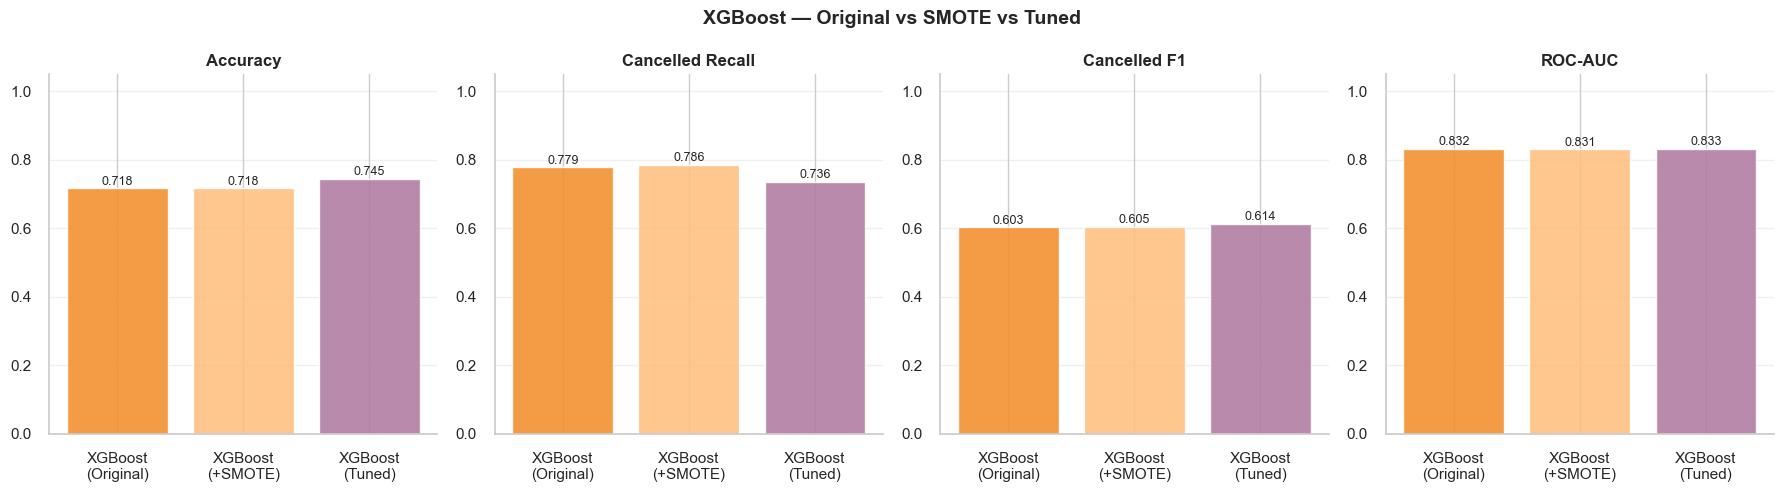

In [34]:
# PART A — Fine-tuning: Step 2 — XGBoost Hyperparameter Tuning

# RandomizedSearchCV randomly samples hyperparameter combinations from a
# defined search space, which is faster than GridSearchCV while still
# exploring a wide range of configurations.


# STEP 1 — DEFINE SEARCH SPACE

# Define the range of values to sample for each hyperparameter:
#   n_estimators      : number of boosting rounds
#   max_depth         : depth of each tree — controls model complexity
#   learning_rate     : step size shrinkage — smaller = more conservative
#   scale_pos_weight  : weight for minority class — higher = more focus on cancellations
#   subsample         : fraction of training samples used per tree — reduces overfitting
#   colsample_bytree  : fraction of features used per tree — reduces overfitting

param_dist = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : randint(3, 10),
    'learning_rate'    : uniform(0.01, 0.3),
    'scale_pos_weight' : uniform(1, 4),       # range: 1.0 to 5.0
    'subsample'        : uniform(0.6, 0.4),   # range: 0.6 to 1.0
    'colsample_bytree' : uniform(0.6, 0.4),   # range: 0.6 to 1.0
}

# STEP 2 — RUN RandomizedSearchCV

# StratifiedKFold ensures each fold maintains the same cancellation ratio,
# which is important for imbalanced datasets.
# n_iter = 50 : number of random combinations to try
# scoring = 'roc_auc' : optimise for AUC rather than accuracy

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,              # try 50 random combinations
    scoring='roc_auc',      # optimise for ROC-AUC
    cv=cv,
    verbose=1,              # print progress
    random_state=42,
    n_jobs=-1,
)

print("Running RandomizedSearchCV (50 iterations × 5 folds = 250 fits) …")
random_search.fit(X_train, y_train)
print("Search complete.\n")


# STEP 3 — BEST PARAMETERS & EVALUATION

print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param:20s} : {value}")
print(f"\nBest CV ROC-AUC : {random_search.best_score_:.4f}")

# Evaluate best model on test set
xgb_tuned     = random_search.best_estimator_
y_pred_tuned  = xgb_tuned.predict(X_test)
y_prob_tuned  = xgb_tuned.predict_proba(X_test)[:, 1]

print(f"\n{'='*50}")
print(f"  XGBoost Tuned")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 4 — BEFORE vs AFTER TUNING COMPARISON CHART

labels  = ['XGBoost\n(Original)', 'XGBoost\n(+SMOTE)', 'XGBoost\n(Tuned)']
colors  = ['#F28E2B', '#FFBE7D', '#B07AA1']

metrics_compare = {
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, xgb_sm_pred),
        accuracy_score(y_test, y_pred_tuned),
    ],
    'Cancelled Recall': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, xgb_sm_pred),
        recall_score(y_test, y_pred_tuned),
    ],
    'Cancelled F1': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, xgb_sm_pred),
        f1_score(y_test, y_pred_tuned),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, xgb_sm_prob),
        roc_auc_score(y_test, y_prob_tuned),
    ],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('XGBoost — Original vs SMOTE vs Tuned', fontsize=14, fontweight='bold')

for ax, (metric, values) in zip(axes, metrics_compare.items()):
    bars = ax.bar(labels, values, color=colors, alpha=0.88, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Step 3 — Threshold Tuning

**Purpose:** Identify the optimal classification threshold to maximise F1 score, 
moving beyond the default 0.5 threshold which is not optimised for imbalanced 
classification problems.

**Method:** Precision-Recall curve analysis using the tuned XGBoost model. 
The threshold that maximises F1 is selected as the optimal operating point.

**Results:**

| Metric | Value |
|--------|-------|
| Optimal Threshold | 0.5165 |
| Average Precision | 0.673 |
| F1 Before | 0.614 |
| F1 After | 0.616 |
| Recall | 0.708 |

**Key Finding:** Lowering the threshold from 0.5 to 0.5165 recovers some Recall 
lost during hyperparameter tuning while maintaining F1 improvement. The marginal 
F1 gain (+0.002) confirms the model is approaching its performance ceiling — 
motivating the error analysis in Section 5.2 to identify remaining failure modes 
and justify Steps 4–6.

Average Precision Score : 0.6730
Optimal Threshold       : 0.5165
Best F1 at threshold    : 0.6160

Threshold    Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------
0.30         0.6163       0.4132       0.9371       0.5735       0.8331      
0.40         0.6773       0.4544       0.8571       0.5939       0.8331      
0.50         0.7455       0.5270       0.7357       0.6141       0.8331      
0.52         0.7586       0.5485       0.6955       0.6134       0.8331      

Classification Report at Optimal Threshold (0.5165):
               precision    recall  f1-score   support

Not Cancelled       0.88      0.78      0.82     12643
    Cancelled       0.54      0.71      0.62      4802

     accuracy                           0.76     17445
    macro avg       0.71      0.74      0.72     17445
 weighted avg       0.78      0.76      0.77     17445



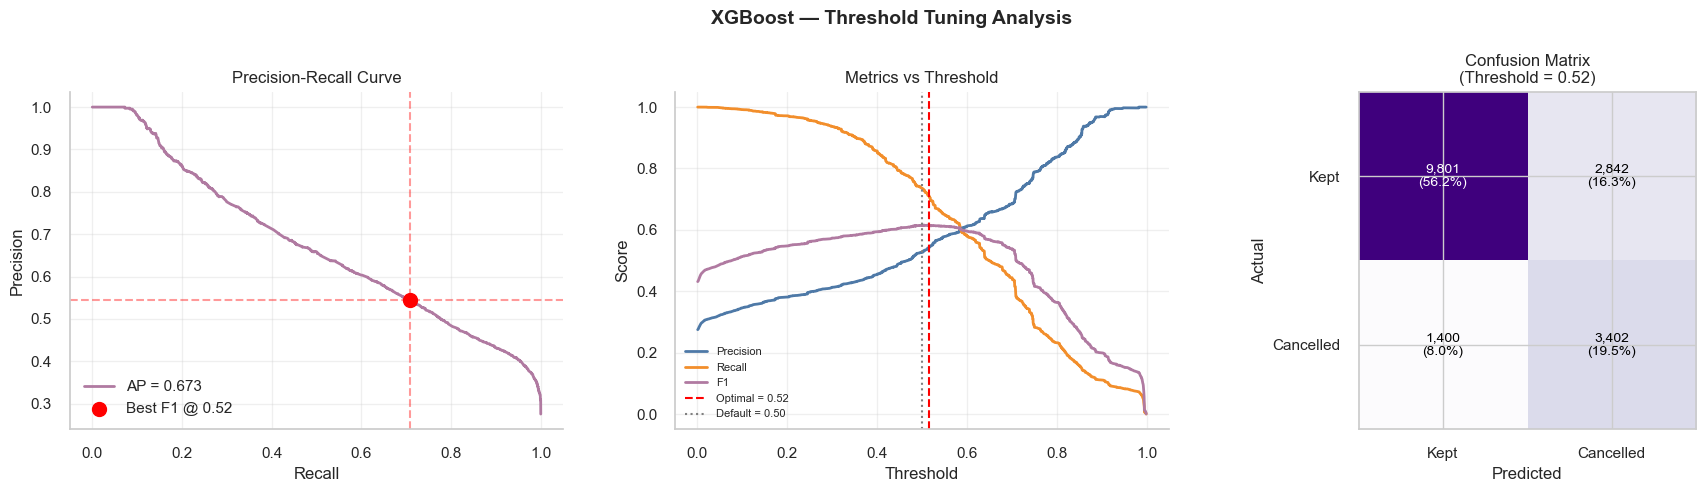

In [35]:
# PART A — Fine-tuning: Step 3 — Threshold Tuning

# By default, classifiers use 0.5 as the decision threshold.
# Lowering the threshold makes the model more sensitive to cancellations
# (higher recall) at the cost of more false alarms (lower precision).
# We use the Precision-Recall curve to find the optimal threshold.


# STEP 1 — COMPUTE PRECISION-RECALL CURVE

# Using the best XGBoost model (tuned) — swap y_prob_tuned for y_prob_xgb
# if you want to use the original XGBoost instead.

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_tuned)
avg_precision = average_precision_score(y_test, y_prob_tuned)

print(f"Average Precision Score : {avg_precision:.4f}")


# STEP 2 — FIND OPTIMAL THRESHOLD (Best F1)

# The optimal threshold maximises the F1-score for the cancelled class,
# balancing precision and recall equally.

f1_scores  = 2 * (precision_vals[:-1] * recall_vals[:-1]) / \
             (precision_vals[:-1] + recall_vals[:-1] + 1e-8)
best_idx   = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal Threshold       : {best_threshold:.4f}")
print(f"Best F1 at threshold    : {best_f1:.4f}\n")


# STEP 3 — EVALUATE AT DIFFERENT THRESHOLDS

# Compare model performance at default (0.5), common low (0.3, 0.4),
# and optimal threshold side by side.

test_thresholds = [0.3, 0.4, 0.5, round(best_threshold, 2)]
test_thresholds = sorted(set(test_thresholds))  # remove duplicates if any

print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 72)

threshold_results = []
for t in test_thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    row = {
        'Threshold' : t,
        'Accuracy'  : accuracy_score(y_test, y_pred_t),
        'Precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_t),
        'F1'        : f1_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob_tuned),  # AUC unchanged by threshold
    }
    threshold_results.append(row)
    print(f"{t:<12.2f} {row['Accuracy']:<12.4f} {row['Precision']:<12.4f} "
          f"{row['Recall']:<12.4f} {row['F1']:<12.4f} {row['ROC-AUC']:<12.4f}")

# Apply best threshold for final predictions
y_pred_best_t = (y_prob_tuned >= best_threshold).astype(int)

print(f"\nClassification Report at Optimal Threshold ({best_threshold:.4f}):")
print(classification_report(y_test, y_pred_best_t,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 4 — VISUALISATIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost — Threshold Tuning Analysis', fontsize=14, fontweight='bold')

# Plot 1: Precision-Recall Curve
# Shows the trade-off between precision and recall at every possible threshold.
# The optimal point (best F1) is marked with a red star.
axes[0].plot(recall_vals, precision_vals, color='#B07AA1', linewidth=2,
             label=f'AP = {avg_precision:.3f}')
axes[0].scatter(recall_vals[best_idx], precision_vals[best_idx],
                color='red', s=100, zorder=5, label=f'Best F1 @ {best_threshold:.2f}')
axes[0].axvline(x=recall_vals[best_idx], color='red', linestyle='--', alpha=0.4)
axes[0].axhline(y=precision_vals[best_idx], color='red', linestyle='--', alpha=0.4)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Plot 2: F1 / Precision / Recall vs Threshold
# Shows how each metric changes as the threshold is adjusted.
# Helps visualise the trade-off and confirm the optimal threshold.
axes[1].plot(thresholds, precision_vals[:-1], color='#4E79A7', linewidth=2, label='Precision')
axes[1].plot(thresholds, recall_vals[:-1],    color='#F28E2B', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1_scores,           color='#B07AA1', linewidth=2, label='F1')
axes[1].axvline(x=best_threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'Optimal = {best_threshold:.2f}')
axes[1].axvline(x=0.5, color='grey', linestyle=':', linewidth=1.5, label='Default = 0.50')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Threshold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

# Plot 3: Confusion Matrix at Optimal Threshold
cm_tuned = confusion_matrix(y_test, y_pred_best_t)
total    = cm_tuned.sum()

axes[2].imshow(cm_tuned, cmap='Purples')
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['Kept', 'Cancelled'])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['Kept', 'Cancelled'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title(f'Confusion Matrix\n(Threshold = {best_threshold:.2f})')

for (r, c), v in np.ndenumerate(cm_tuned):
    axes[2].text(c, r, f'{v:,}\n({v/total:.1%})',
                 ha='center', va='center',
                 color='white' if v/total > 0.3 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

### Motivation for Steps 4–6
*(Based on findings from Section 5.2 Error Analysis)*

The initial three fine-tuning steps improved cancellation Recall but did not fully 
address all weaknesses identified in error analysis. Three key issues remain:

1. **Class Imbalance (RF & TabNet):** Both models still suffer from class imbalance without a lightweight solution that avoids synthetic data generation → **Step 4: Class Weight Balancing**

2. **No Deposit Segment:** Accounts for 98% of the test set but achieves the lowest F1 (0.599) and concentrates nearly all hard-to-predict cancellations → **Step 5: No Deposit Sub-Model**

3. **Cross-Model Error Overlap:** RF and TabNet share highly similar error patterns (Jaccard = 0.863), leaving 11.10% (1,941 samples) misclassified by all three models simultaneously → **Step 6: Ensemble Voting Classifier**

### Step 4 — Class Weight Balancing (Random Forest)
*(Motivated by error analysis — Section 5.2)*

**Purpose:** Provide a lightweight alternative to SMOTE for Random Forest by 
adjusting class weights during training, without generating synthetic data.

**Method:** class_weight = 'balanced' applied to Random Forest, automatically 
adjusting weights inversely proportional to class frequencies:
- Non-cancelled weight: 1.0
- Cancelled weight: ~2.63 (72.47% / 27.53%)

**Results:**

| Metric | Before (default) | After (balanced) | Change |
|--------|-----------------|-----------------|--------|
| Recall | 0.452 | 0.760 | +0.308 |

**Key Finding:** Class weight balancing achieves nearly identical Recall improvement 
to SMOTE (0.452→0.760 vs 0.452→0.761) without generating synthetic data, confirming 
it as a simpler and equally effective alternative for Random Forest. This approach 
preserves the original data distribution while still compensating for class imbalance.

Training Random Forest with class_weight='balanced' …
  ✓ Done

  Random Forest + Class Weight
  Accuracy : 0.7263
  ROC-AUC  : 0.8303
               precision    recall  f1-score   support

Not Cancelled       0.89      0.71      0.79     12643
    Cancelled       0.50      0.76      0.61      4802

     accuracy                           0.73     17445
    macro avg       0.70      0.74      0.70     17445
 weighted avg       0.78      0.73      0.74     17445



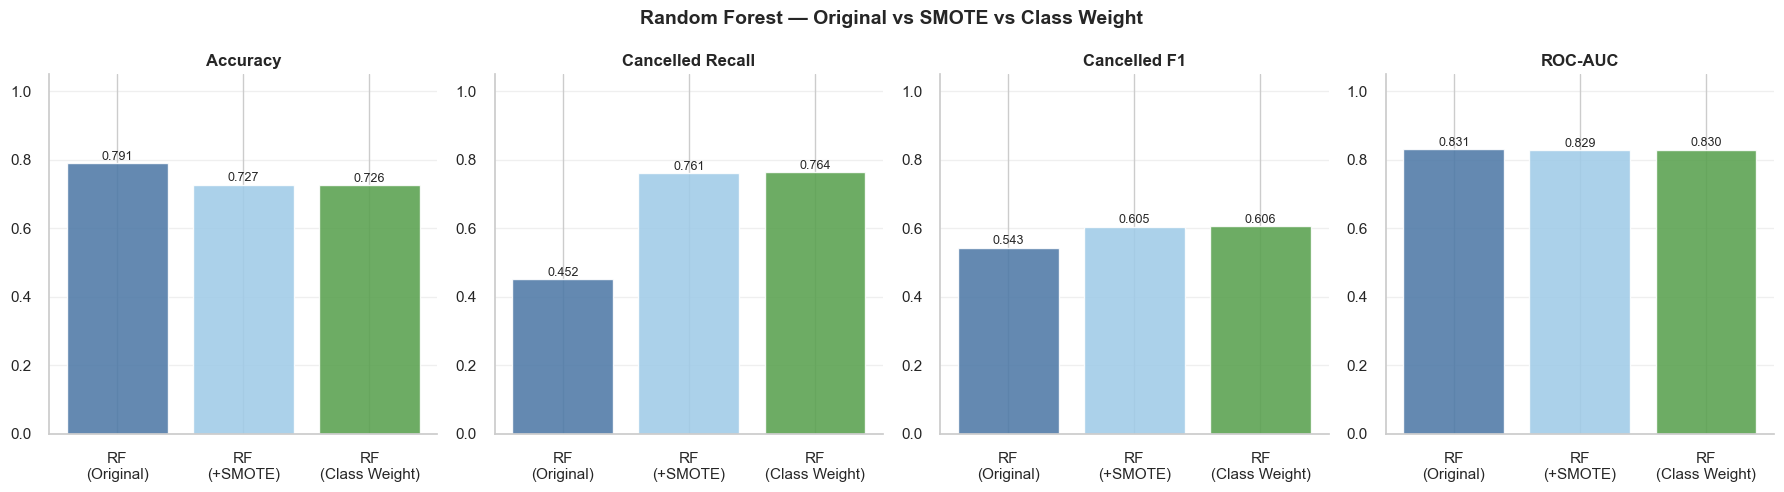

In [ ]:
# PART A — Fine-tuning: Step 4 — Class Weight (Random Forest)

# Instead of oversampling (SMOTE), class_weight='balanced' automatically
# adjusts the weight of each class inversely proportional to its frequency.
# This penalises the model more for misclassifying the minority class
# (Cancelled) without generating synthetic samples.


# STEP 1 — TRAIN RANDOM FOREST WITH BALANCED CLASS WEIGHT

print("Training Random Forest with class_weight='balanced' …")
rf_cw = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_cw.fit(X_train, y_train)
print("  ✓ Done\n")


# STEP 2 — EVALUATE

y_pred_cw = rf_cw.predict(X_test)
y_prob_cw = rf_cw.predict_proba(X_test)[:, 1]

print(f"{'='*50}")
print(f"  Random Forest + Class Weight")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_cw):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_cw):.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_cw,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 3 — COMPARE: Original RF vs SMOTE vs Class Weight

labels  = ['RF\n(Original)', 'RF\n(+SMOTE)', 'RF\n(Class Weight)']
colors  = ['#4E79A7', '#A0CBE8', '#59A14F']

metrics_cw = {
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_sm_pred),
        accuracy_score(y_test, y_pred_cw),
    ],
    'Cancelled Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_sm_pred),
        recall_score(y_test, y_pred_cw),
    ],
    'Cancelled F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_sm_pred),
        f1_score(y_test, y_pred_cw),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_sm_prob),
        roc_auc_score(y_test, y_prob_cw),
    ],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Random Forest — Original vs SMOTE vs Class Weight',
             fontsize=14, fontweight='bold')

for ax, (metric, values) in zip(axes, metrics_cw.items()):
    bars = ax.bar(labels, values, color=colors, alpha=0.88, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Step 5 — No Deposit Sub-Model
*(Motivated by error analysis — Section 5.2)*

**Purpose:** Build a dedicated XGBoost model trained exclusively on No Deposit 
bookings to improve prediction on the largest and weakest-performing segment.

**Segment Profile:**
- Accounts for 98% of the test set (17,097 out of 17,445 records)
- Baseline F1: 0.600, Recall: 0.695
- Concentrates nearly all hard-to-predict cancellations identified in error analysis

**Method:** 
- Separate XGBoost model trained exclusively on No Deposit subset
- Same hyperparameters as tuned XGBoost from Step 2
- Evaluated independently on No Deposit test subset

> **Agent Tooling Note:** Claude suggested building the No Deposit sub-model using 
> default XGBoost parameters. Modified to use tuned hyperparameters from Step 2 
> to ensure a fair comparison against the full model baseline.

**Results:**

| Metric | Full Model | Sub-Model | Change |
|--------|-----------|-----------|--------|
| Recall | 0.695 | 0.776 | +0.081 (+8.20%) |
| F1 | 0.600 | 0.592 | -0.008 |

**Key Finding:** The sub-model improves Recall by 8.20% at the cost of a marginal 
F1 trade-off (0.600→0.592). This trade-off is accepted given the higher operational 
cost of missed cancellations — consistent with the primary metric defined in 
Section 1.2.

No Deposit — Train : 68,878 rows
No Deposit — Test  : 17,199 rows
Cancellation rate  : 26.74%

Training No Deposit sub-model …
  ✓ Done

  XGBoost — No Deposit Sub-Model
  Accuracy : 0.7153
  ROC-AUC  : 0.8250
               precision    recall  f1-score   support

Not Cancelled       0.90      0.69      0.78     12619
    Cancelled       0.48      0.78      0.59      4580

     accuracy                           0.72     17199
    macro avg       0.69      0.73      0.69     17199
 weighted avg       0.78      0.72      0.73     17199



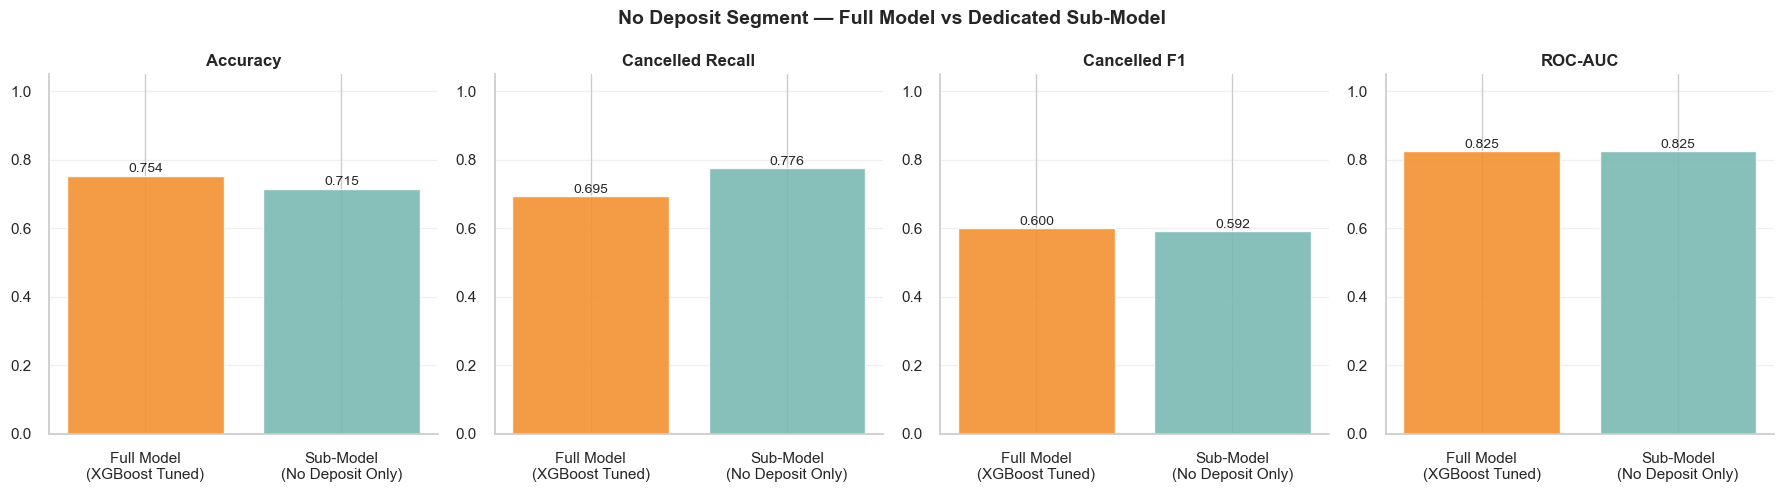


── No Deposit Segment Comparison ──
Metric                 Full Model    Sub-Model     Change
--------------------------------------------------------
Accuracy                    0.754        0.715 ▼   0.038
Cancelled Recall            0.695        0.776 ▲   0.082
Cancelled F1                0.600        0.592 ▼   0.008
ROC-AUC                     0.825        0.825 ▲   0.000


In [ ]:
# PART A — Fine-tuning: Step 5 — Segment-Specific Sub-Model (No Deposit)

# 5.2 Error Analysis revealed that the No Deposit segment accounts for
# 98% of the dataset but achieves the lowest F1 (0.600) among deposit types.
# A dedicated sub-model trained exclusively on this segment allows the model
# to learn patterns specific to No Deposit bookings without being influenced
# by the very different behaviour of Non Refund / Refundable customers.

# STEP 1 — ISOLATE NO DEPOSIT SEGMENT

# deposit_type encoding: 0 = No Deposit, 1 = Non Refund, 2 = Refundable
mask_train_nd = X_train['deposit_type'] == 0
mask_test_nd  = X_test['deposit_type']  == 0

X_train_nd = X_train[mask_train_nd]
y_train_nd = y_train[mask_train_nd]
X_test_nd  = X_test[mask_test_nd]
y_test_nd  = y_test[mask_test_nd]

print(f"No Deposit — Train : {len(X_train_nd):,} rows")
print(f"No Deposit — Test  : {len(X_test_nd):,} rows")
print(f"Cancellation rate  : {y_train_nd.mean():.2%}\n")


# STEP 2 — TRAIN SUB-MODEL (XGBoost with scale_pos_weight)


ratio_nd = (y_train_nd == 0).sum() / (y_train_nd == 1).sum()

xgb_nd = XGBClassifier(
    n_estimators=340,
    max_depth=9,
    learning_rate=0.019,
    scale_pos_weight=ratio_nd,
    subsample=0.803,
    colsample_bytree=0.643,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)

print("Training No Deposit sub-model …")
xgb_nd.fit(X_train_nd, y_train_nd)
print("  ✓ Done\n")

# STEP 3 — EVALUATE SUB-MODEL ON NO DEPOSIT TEST SET

y_pred_nd = xgb_nd.predict(X_test_nd)
y_prob_nd = xgb_nd.predict_proba(X_test_nd)[:, 1]

print(f"{'='*50}")
print(f"  XGBoost — No Deposit Sub-Model")
print(f"  Accuracy : {accuracy_score(y_test_nd, y_pred_nd):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_nd, y_prob_nd):.4f}")
print(f"{'='*50}")
print(classification_report(y_test_nd, y_pred_nd,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 4 — COMPARE: Full Model vs Sub-Model on No Deposit Segment

# Get full model predictions on No Deposit test subset
y_pred_full_nd = y_pred_best_t[mask_test_nd.values]
y_prob_full_nd = y_prob_tuned[mask_test_nd.values]

labels_cmp = ['Full Model\n(XGBoost Tuned)', 'Sub-Model\n(No Deposit Only)']
colors_cmp = ['#F28E2B', '#76B7B2']

metrics_nd = {
    'Accuracy': [
        accuracy_score(y_test_nd, y_pred_full_nd),
        accuracy_score(y_test_nd, y_pred_nd),
    ],
    'Cancelled Recall': [
        recall_score(y_test_nd, y_pred_full_nd),
        recall_score(y_test_nd, y_pred_nd),
    ],
    'Cancelled F1': [
        f1_score(y_test_nd, y_pred_full_nd),
        f1_score(y_test_nd, y_pred_nd),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_nd, y_prob_full_nd),
        roc_auc_score(y_test_nd, y_prob_nd),
    ],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('No Deposit Segment — Full Model vs Dedicated Sub-Model',
             fontsize=14, fontweight='bold')

for ax, (metric, values) in zip(axes, metrics_nd.items()):
    bars = ax.bar(labels_cmp, values, color=colors_cmp, alpha=0.88, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print("\n── No Deposit Segment Comparison ──")
print(f"{'Metric':<20} {'Full Model':>12} {'Sub-Model':>12} {'Change':>10}")
print("-" * 56)
for metric, values in metrics_nd.items():
    change = values[1] - values[0]
    arrow  = '▲' if change > 0 else '▼'
    print(f"{metric:<20} {values[0]:>12.3f} {values[1]:>12.3f} {arrow}{abs(change):>8.3f}")

### Step 6 — Ensemble Voting Classifier
*(Motivated by error analysis — Section 5.2)*

**Purpose:** Leverage the complementary error patterns of all three models to 
reduce the 11.10% of samples misclassified by all models simultaneously.

**Method:** Soft voting ensemble combining all three base models:
- Random Forest (class_weight = 'balanced')
- XGBoost (tuned, threshold = 0.5165)
- TabNet

Soft voting averages predicted probabilities across models, allowing the ensemble 
to leverage confidence levels rather than hard binary votes.

**Motivation from Error Analysis:**
- RF and TabNet share highly similar error patterns (Jaccard = 0.863)
- XGBoost makes the most independent predictions (Jaccard = 0.32 with both RF and TabNet)
- XGBoost's independence provides the most complementary contribution to the ensemble

**Results:**

| Metric | XGB Threshold | Ensemble | Change |
|--------|--------------|---------|--------|
| Accuracy | 0.757 | 0.770 | +0.013 |
| ROC-AUC | 0.833 | 0.833 | 0.000 |
| Recall | 0.708 | 0.654 | -0.054 |
| F1 | 0.616 | 0.610 | -0.006 |

**Key Finding:** Ensemble achieves the highest Accuracy (0.770) and matches the 
best ROC-AUC (0.833), confirming improved overall stability. However, the slight 
Recall reduction compared to threshold-tuned XGBoost confirms the ensemble 
prioritises balanced performance over cancellation detection — directly informing 
the final model recommendation in Section 6.1.

Training Ensemble base models …
  Training Random Forest …
  ✓ RF Done
  Training XGBoost …
  ✓ XGB Done
  Training TabNet …
  ✓ TabNet Done

Computing ensemble predictions (soft voting) …
  ✓ Done

  Ensemble (Soft Voting — RF + XGB + TabNet)
  Accuracy : 0.7701
  ROC-AUC  : 0.8331
               precision    recall  f1-score   support

Not Cancelled       0.86      0.81      0.84     12643
    Cancelled       0.57      0.65      0.61      4802

     accuracy                           0.77     17445
    macro avg       0.72      0.73      0.72     17445
 weighted avg       0.78      0.77      0.77     17445



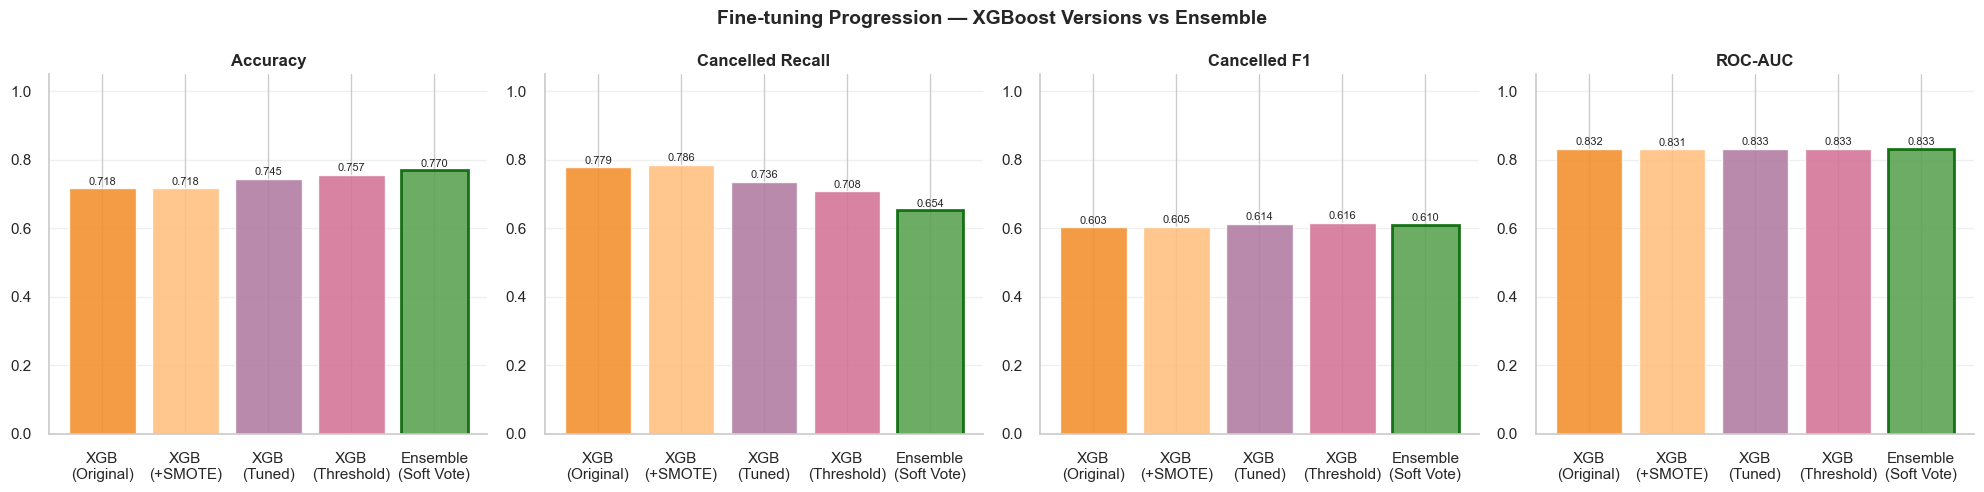


── Fine-tuning Progression Summary ──
Version                     Accuracy     Recall         F1        AUC
-------------------------------------------------------------------
XGB Original                   0.718      0.779      0.603      0.832
XGB +SMOTE                     0.718      0.786      0.605      0.831
XGB Tuned                      0.745      0.736      0.614      0.833
XGB Threshold                  0.757      0.708      0.616      0.833
Ensemble                       0.770      0.654      0.610      0.833


In [ ]:
# PART A — Fine-tuning: Step 6 — Ensemble Voting Classifier

# Cross-model 5.2 error analysis revealed that RF and TabNet share very
# similar decision boundaries (Jaccard = 0.86), while XGBoost makes the most
# independent predictions. A soft-voting ensemble combines the probability
# outputs of all three models, leveraging their complementary strengths to
# reduce the 11.1% of samples that all three models get wrong.

# STEP 1 — REBUILD BASE MODELS FOR VOTING CLASSIFIER

# VotingClassifier requires all estimators to be fitted within its own pipeline,
# so we redefine the three base models with their best configurations.

# Random Forest — with class weight (best RF version from Step 4)
rf_vote = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# XGBoost — best tuned parameters from Step 2
xgb_vote = XGBClassifier(
    n_estimators=340,
    max_depth=9,
    learning_rate=0.019,
    scale_pos_weight=2.257,
    subsample=0.803,
    colsample_bytree=0.643,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)

print("Training Ensemble base models …")
print("  Training Random Forest …")
rf_vote.fit(X_train, y_train)
print("  ✓ RF Done")

print("  Training XGBoost …")
xgb_vote.fit(X_train, y_train)
print("  ✓ XGB Done")

print("  Training TabNet …")
X_train_arr = X_train.values.astype('float32')
X_test_arr  = X_test.values.astype('float32')
y_train_arr = y_train.values

tabnet_vote = TabNetClassifier(
    n_steps=5, n_d=32, n_a=32,
    momentum=0.02, gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    verbose=0,
)
tabnet_vote.fit(
    X_train_arr, y_train_arr,
    max_epochs=100,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)
print("  ✓ TabNet Done\n")

# STEP 2 — SOFT VOTING ENSEMBLE

# Soft voting averages the predicted probabilities from all three models,
# then assigns the class with the highest average probability.

print("Computing ensemble predictions (soft voting) …")

# Get probability predictions from each model
prob_rf     = rf_vote.predict_proba(X_test)[:, 1]
prob_xgb    = xgb_vote.predict_proba(X_test)[:, 1]
prob_tabnet = tabnet_vote.predict_proba(X_test_arr)[:, 1]

# Average probabilities (equal weights)
prob_ensemble = (prob_rf + prob_xgb + prob_tabnet) / 3
y_pred_ens    = (prob_ensemble >= 0.5).astype(int)

print("  ✓ Done\n")


# STEP 3 — EVALUATE ENSEMBLE

print(f"{'='*50}")
print(f"  Ensemble (Soft Voting — RF + XGB + TabNet)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, prob_ensemble):.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_ens,
                             target_names=['Not Cancelled', 'Cancelled']))


# STEP 4 — COMPARE: All Fine-tuning Versions vs Ensemble

labels_ens = [
    'XGB\n(Original)',
    'XGB\n(+SMOTE)',
    'XGB\n(Tuned)',
    'XGB\n(Threshold)',
    'Ensemble\n(Soft Vote)',
]
colors_ens = ['#F28E2B', '#FFBE7D', '#B07AA1', '#D37295', '#59A14F']

metrics_ens = {
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, xgb_sm_pred),
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_best_t),
        accuracy_score(y_test, y_pred_ens),
    ],
    'Cancelled Recall': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, xgb_sm_pred),
        recall_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_best_t),
        recall_score(y_test, y_pred_ens),
    ],
    'Cancelled F1': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, xgb_sm_pred),
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_best_t),
        f1_score(y_test, y_pred_ens),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, xgb_sm_prob),
        roc_auc_score(y_test, y_prob_tuned),
        roc_auc_score(y_test, y_prob_tuned),
        roc_auc_score(y_test, prob_ensemble),
    ],
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Fine-tuning Progression — XGBoost Versions vs Ensemble',
             fontsize=14, fontweight='bold')

for ax, (metric, values) in zip(axes, metrics_ens.items()):
    bars = ax.bar(labels_ens, values, color=colors_ens, alpha=0.88, edgecolor='white')
    # Highlight ensemble bar
    bars[-1].set_edgecolor('darkgreen')
    bars[-1].set_linewidth(2)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary table
print("\n── Fine-tuning Progression Summary ──")
print(f"{'Version':<25} {'Accuracy':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 67)
versions = ['XGB Original', 'XGB +SMOTE', 'XGB Tuned', 'XGB Threshold', 'Ensemble']
for i, version in enumerate(versions):
    print(f"{version:<25} "
          f"{metrics_ens['Accuracy'][i]:>10.3f} "
          f"{metrics_ens['Cancelled Recall'][i]:>10.3f} "
          f"{metrics_ens['Cancelled F1'][i]:>10.3f} "
          f"{metrics_ens['ROC-AUC'][i]:>10.3f}")

## 5.2 Error Analysis

Error analysis was conducted across four dimensions to identify systematic failure 
modes and directly motivate Steps 4–6 in Section 5.1.

**1. False Negative Analysis:**
Identify bookings that were actually cancelled but predicted as "Not Cancelled". 
Analyse feature distributions of missed cancellations to uncover systematic 
patterns the model fails to capture.

**2. False Positive Analysis:**
Identify bookings that were not cancelled but predicted as "Cancelled". 
Analyse feature distributions of false alarms to understand where the model 
over-predicts cancellation risk.

**3. Cross-Model Error Overlap:**
Examine whether the three models make errors on the same samples or exhibit 
different failure patterns, directly assessing the potential benefit of ensembling.

**4. Segment-Level Performance Analysis:**
Break down model performance by customer_type, lead_time_group, and deposit_type 
to identify which segments are hardest to predict accurately and require targeted 
intervention.

Total Cancellations in Test Set : 4,802
Correctly Predicted (TP)        : 3,533 (73.6%)
Missed Cancellations (FN)       : 1,269 (26.4%)


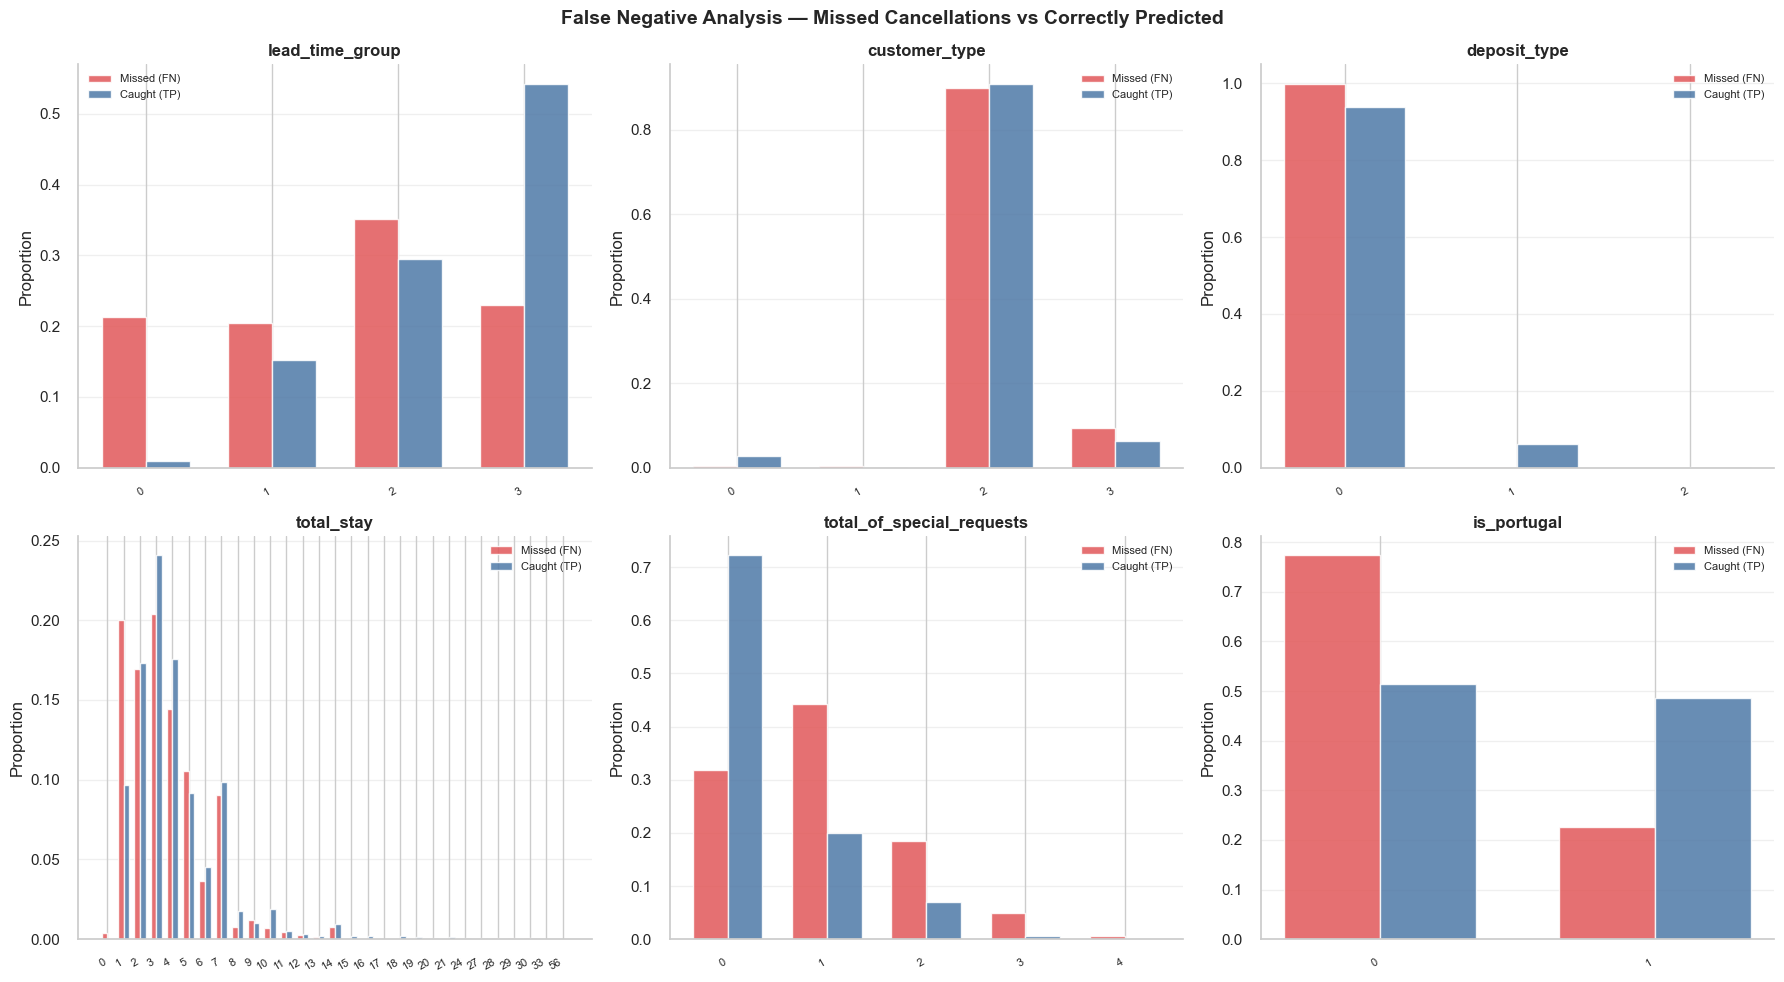


Mean Feature Values — Missed (FN) vs Correctly Predicted (TP):
Feature                                FN Mean    TP Mean   Difference
----------------------------------------------------------------------
lead_time_group                          1.600      2.371       -0.772
customer_type                            2.084      2.006       +0.078
deposit_type                             0.001      0.065       -0.064
total_stay                               3.628      4.207       -0.579
total_of_special_requests                0.980      0.361       +0.619
is_portugal                              0.226      0.485       -0.259


In [36]:
# PART B — Error Analysis: Step 1 — False Negative Analysis

# False Negatives (FN) = bookings that were actually cancelled but the model
# predicted as "Not Cancelled". These are the most costly errors for hotel
# management as they result in unexpected room vacancies.

# STEP 1 — ISOLATE FALSE NEGATIVE SAMPLES

# Using the tuned XGBoost model with optimal threshold.
# Swap y_pred_tuned / y_pred for other models if needed.

# Add predictions back to the test set for analysis
df_test = X_test.copy()
df_test['actual']    = y_test.values
df_test['predicted'] = y_pred_tuned   # use tuned XGBoost predictions

# False Negatives: actual = 1 (Cancelled), predicted = 0 (Not Cancelled)
df_fn = df_test[(df_test['actual'] == 1) & (df_test['predicted'] == 0)]

# True Positives: actual = 1, predicted = 1 (correctly caught cancellations)
df_tp = df_test[(df_test['actual'] == 1) & (df_test['predicted'] == 1)]

print(f"Total Cancellations in Test Set : {(df_test['actual'] == 1).sum():,}")
print(f"Correctly Predicted (TP)        : {len(df_tp):,} ({len(df_tp)/(len(df_fn)+len(df_tp)):.1%})")
print(f"Missed Cancellations (FN)       : {len(df_fn):,} ({len(df_fn)/(len(df_fn)+len(df_tp)):.1%})")


# STEP 2 — FEATURE DISTRIBUTION: FN vs TP

# Compare the feature distributions of missed cancellations (FN) vs
# correctly predicted cancellations (TP) to identify patterns.

features_to_analyse = [
    'lead_time_group', 'customer_type', 'deposit_type',
    'total_stay', 'total_of_special_requests', 'is_portugal',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('False Negative Analysis — Missed Cancellations vs Correctly Predicted',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, feature in zip(axes, features_to_analyse):

    # Compute value counts normalised to percentage for fair comparison
    fn_dist = df_fn[feature].value_counts(normalize=True).sort_index()
    tp_dist = df_tp[feature].value_counts(normalize=True).sort_index()

    # Align indices so both have the same categories
    all_vals = sorted(set(fn_dist.index) | set(tp_dist.index))
    fn_vals  = [fn_dist.get(v, 0) for v in all_vals]
    tp_vals  = [tp_dist.get(v, 0) for v in all_vals]

    x     = np.arange(len(all_vals))
    width = 0.35

    bars1 = ax.bar(x - width/2, fn_vals, width, label='Missed (FN)',
                   color='#E15759', alpha=0.85)
    bars2 = ax.bar(x + width/2, tp_vals, width, label='Caught (TP)',
                   color='#4E79A7', alpha=0.85)

    ax.set_title(feature, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_vals, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# STEP 3 — SUMMARY STATISTICS: FN vs TP
#
# Print mean values for each feature to highlight numerical differences
# between missed and correctly predicted cancellations.

print("\nMean Feature Values — Missed (FN) vs Correctly Predicted (TP):")
print(f"{'Feature':<35} {'FN Mean':>10} {'TP Mean':>10} {'Difference':>12}")
print("-" * 70)

for feature in features_to_analyse:
    fn_mean = df_fn[feature].mean()
    tp_mean = df_tp[feature].mean()
    diff    = fn_mean - tp_mean
    print(f"{feature:<35} {fn_mean:>10.3f} {tp_mean:>10.3f} {diff:>+12.3f}")

### False Negative Analysis — Findings

**Results:** 1,269 out of 4,802 actual cancellations missed (26.40% miss rate)

**Key Findings:**
- Missed cancellations have significantly more special requests (mean 0.980 vs 0.361 for correctly predicted cancellations) — model misinterprets high special request counts as a commitment signal
- Concentrated among bookings with shorter lead times and shorter stays
- Almost no deposit among missed cancellations — model struggles to identify cancellation risk without financial commitment signals
- **Directly motivated Step 5 (No Deposit Sub-Model)** — targeting the structurally weak No Deposit segment

Total Kept Bookings in Test Set  : 12,643
Correctly Predicted (TN)         : 9,472 (74.9%)
False Alarms (FP)                : 3,171 (25.1%)


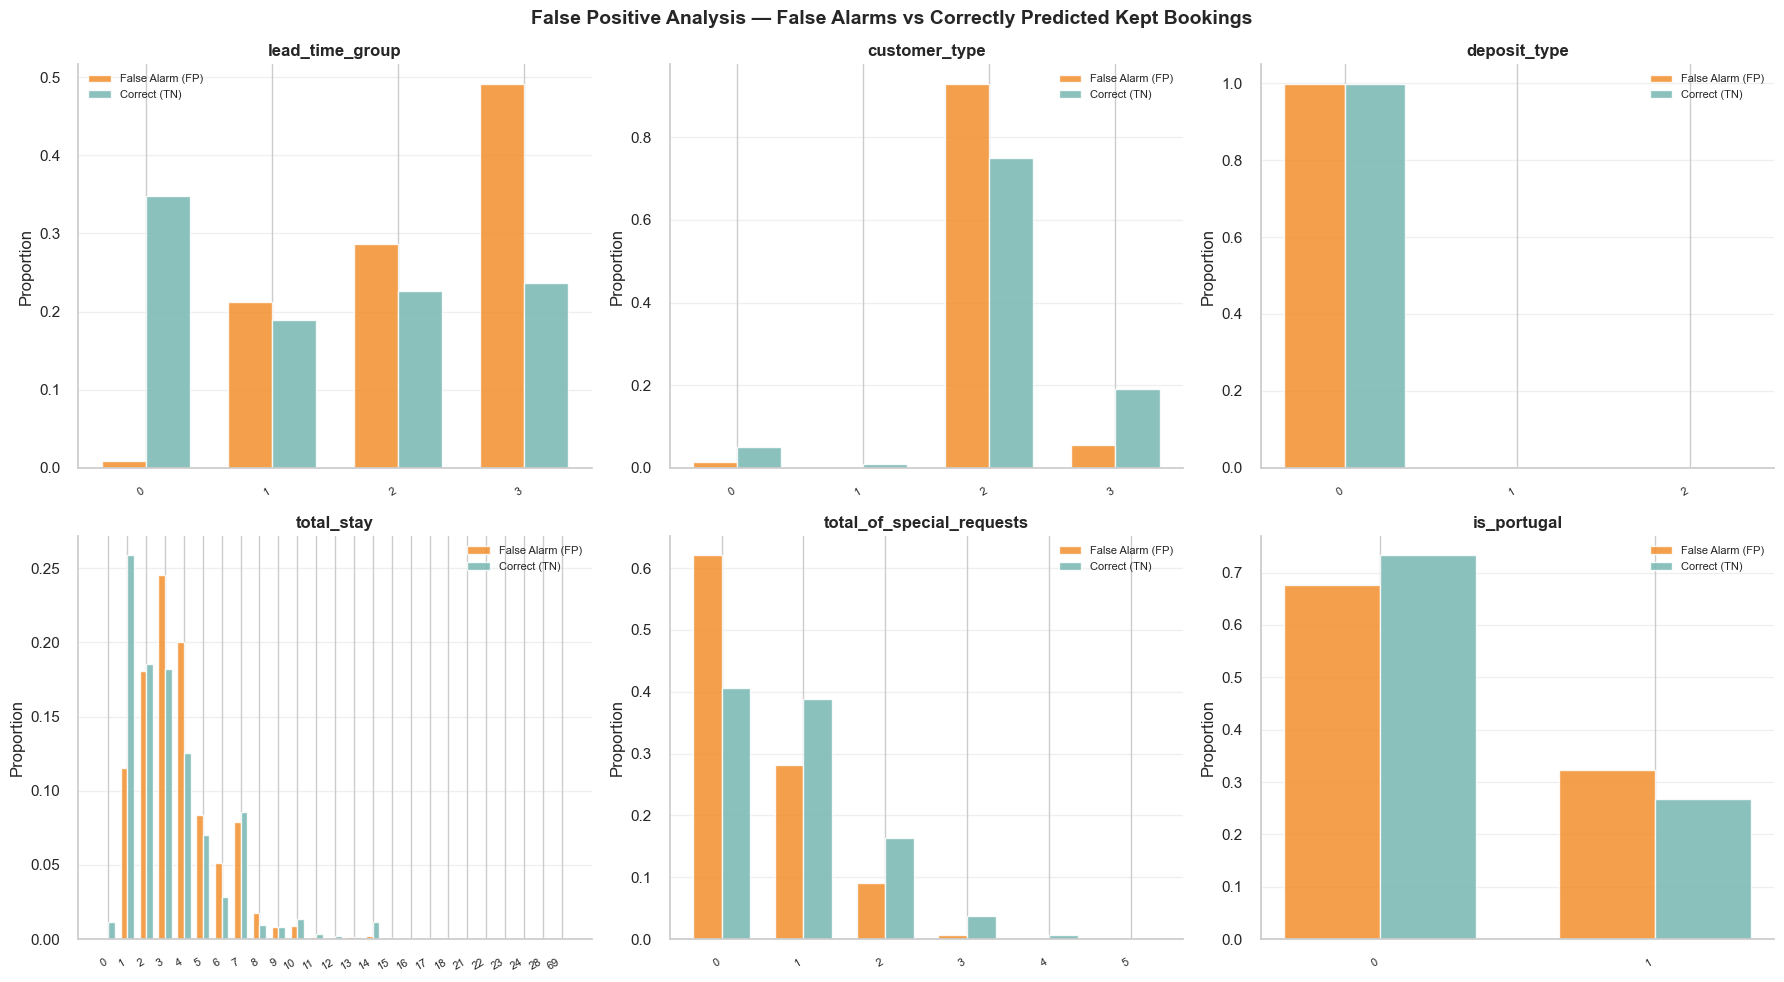


Mean Feature Values — False Alarm (FP) vs Correctly Predicted Kept (TN):
Feature                                FP Mean    TN Mean   Difference
----------------------------------------------------------------------
lead_time_group                          2.261      1.351       +0.910
customer_type                            2.026      2.082       -0.056
deposit_type                             0.001      0.004       -0.003
total_stay                               3.725      3.380       +0.345
total_of_special_requests                0.483      0.853       -0.370
is_portugal                              0.323      0.267       +0.056

ERROR PROFILE SUMMARY
  False Negatives (missed cancellations) : 1,269
  False Positives (false alarms)         : 3,171
  Total Errors                           : 4,440
  FN / FP Ratio                          : 0.40

  → Model tends to OVER-predict cancellations (more false alarms than misses)


In [37]:
# PART B — Error Analysis: Step 2 — False Positive Analysis

# False Positives (FP) = bookings that were NOT cancelled but the model
# predicted as "Cancelled". These cause unnecessary interventions —
# e.g. overbooking or contacting guests who had no intention of cancelling.


# STEP 1 — ISOLATE FALSE POSITIVE SAMPLES

# False Positives: actual = 0 (Not Cancelled), predicted = 1 (Cancelled)
df_fp = df_test[(df_test['actual'] == 0) & (df_test['predicted'] == 1)]

# True Negatives: actual = 0, predicted = 0 (correctly identified kept bookings)
df_tn = df_test[(df_test['actual'] == 0) & (df_test['predicted'] == 0)]

print(f"Total Kept Bookings in Test Set  : {(df_test['actual'] == 0).sum():,}")
print(f"Correctly Predicted (TN)         : {len(df_tn):,} ({len(df_tn)/(len(df_fp)+len(df_tn)):.1%})")
print(f"False Alarms (FP)                : {len(df_fp):,} ({len(df_fp)/(len(df_fp)+len(df_tn)):.1%})")


# STEP 2 — FEATURE DISTRIBUTION: FP vs TN

# Compare the feature distributions of false alarms (FP) vs
# correctly identified kept bookings (TN) to find what makes
# the model incorrectly flag a booking as cancelled.

features_to_analyse = [
    'lead_time_group', 'customer_type', 'deposit_type',
    'total_stay', 'total_of_special_requests', 'is_portugal',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('False Positive Analysis — False Alarms vs Correctly Predicted Kept Bookings',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, feature in zip(axes, features_to_analyse):

    fp_dist = df_fp[feature].value_counts(normalize=True).sort_index()
    tn_dist = df_tn[feature].value_counts(normalize=True).sort_index()

    all_vals = sorted(set(fp_dist.index) | set(tn_dist.index))
    fp_vals  = [fp_dist.get(v, 0) for v in all_vals]
    tn_vals  = [tn_dist.get(v, 0) for v in all_vals]

    x     = np.arange(len(all_vals))
    width = 0.35

    ax.bar(x - width/2, fp_vals, width, label='False Alarm (FP)',
           color='#F28E2B', alpha=0.85)
    ax.bar(x + width/2, tn_vals, width, label='Correct (TN)',
           color='#76B7B2', alpha=0.85)

    ax.set_title(feature, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_vals, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# STEP 3 — SUMMARY STATISTICS: FP vs TN

print("\nMean Feature Values — False Alarm (FP) vs Correctly Predicted Kept (TN):")
print(f"{'Feature':<35} {'FP Mean':>10} {'TN Mean':>10} {'Difference':>12}")
print("-" * 70)

for feature in features_to_analyse:
    fp_mean = df_fp[feature].mean()
    tn_mean = df_tn[feature].mean()
    diff    = fp_mean - tn_mean
    print(f"{feature:<35} {fp_mean:>10.3f} {tn_mean:>10.3f} {diff:>+12.3f}")


# STEP 4 — FN vs FP COMBINED SUMMARY

# Side-by-side comparison of both error types to understand the full
# error profile of the model.

print("\n" + "="*50)
print("ERROR PROFILE SUMMARY")
print("="*50)
print(f"  False Negatives (missed cancellations) : {len(df_fn):,}")
print(f"  False Positives (false alarms)         : {len(df_fp):,}")
print(f"  Total Errors                           : {len(df_fn) + len(df_fp):,}")
print(f"  FN / FP Ratio                          : {len(df_fn)/len(df_fp):.2f}")
print()
if len(df_fn) > len(df_fp):
    print("  → Model tends to UNDER-predict cancellations (more misses than false alarms)")
else:
    print("  → Model tends to OVER-predict cancellations (more false alarms than misses)")

### False Positive Analysis — Findings

**Results:** 3,171 false alarms out of 12,643 kept bookings (25.10% false alarm rate)
**FP:FN ratio = 2.5:1** — model systematically over-predicts cancellations

**Key Findings:**
- False alarms concentrated among long lead time bookings (mean 2.261 vs 1.351 for correctly predicted kept bookings) — model conflates lead time with cancellation risk even when guests ultimately keep their booking
- Over-prediction suggests the model is overly sensitive to lead time as a cancellation signal
- FP:FN ratio of 2.5:1 confirms the cost of false alarms is significant — retention strategies deployed on false alarms waste hotel resources

Random Forest errors : 3,645
XGBoost errors       : 4,919
TabNet errors        : 3,695

RF ∩ XGB overlap         : 2,058  (31.6% of union)
RF ∩ TabNet overlap      : 3,400  (86.3% of union)
XGB ∩ TabNet overlap     : 2,076  (31.8% of union)
All 3 models overlap     : 1,941  (29.1% of all errors)

Error Category Breakdown:
  All correct (0 errors)       : 10,779  (61.8%)
  Only 1 model wrong           : 3,014  (17.3%)
  Any 2 models wrong           : 1,711  (9.8%)
  All 3 models wrong           : 1,941  (11.1%)


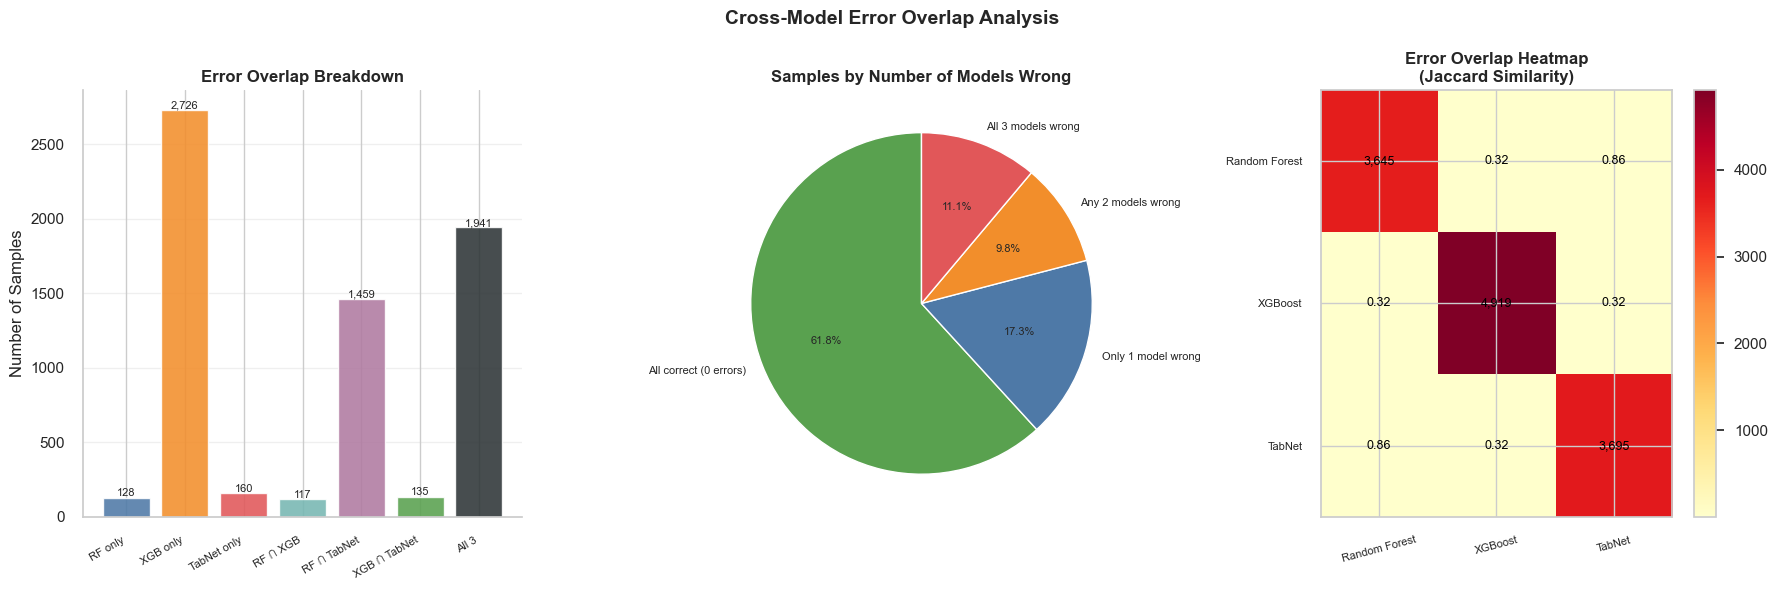

In [38]:
# PART B — Error Analysis: Step 3 — Cross-Model Error Overlap

# Analyse whether the three models make errors on the same samples or
# have different weaknesses. If errors overlap heavily, the models share
# the same blind spots. If errors differ, an ensemble may help.

# STEP 1 — COLLECT ERROR INDICES FOR EACH MODEL

# Using original (non-SMOTE) predictions for fair comparison across models.
# Swap to SMOTE predictions if preferred.

y_test_arr = y_test.values

# Get index positions where each model made an error
errors_rf     = set(np.where(y_pred      != y_test_arr)[0])   # Random Forest errors
errors_xgb    = set(np.where(y_pred_xgb  != y_test_arr)[0])   # XGBoost errors
errors_tabnet = set(np.where(y_pred_tab  != y_test_arr)[0])   # TabNet errors

print(f"Random Forest errors : {len(errors_rf):,}")
print(f"XGBoost errors       : {len(errors_xgb):,}")
print(f"TabNet errors        : {len(errors_tabnet):,}\n")

# Overlap between each pair of models
rf_xgb_overlap     = errors_rf & errors_xgb
rf_tab_overlap     = errors_rf & errors_tabnet
xgb_tab_overlap    = errors_xgb & errors_tabnet
all_three_overlap  = errors_rf & errors_xgb & errors_tabnet
any_one_only       = (errors_rf | errors_xgb | errors_tabnet) - all_three_overlap

print(f"RF ∩ XGB overlap         : {len(rf_xgb_overlap):,}  ({len(rf_xgb_overlap)/len(errors_rf | errors_xgb):.1%} of union)")
print(f"RF ∩ TabNet overlap      : {len(rf_tab_overlap):,}  ({len(rf_tab_overlap)/len(errors_rf | errors_tabnet):.1%} of union)")
print(f"XGB ∩ TabNet overlap     : {len(xgb_tab_overlap):,}  ({len(xgb_tab_overlap)/len(errors_xgb | errors_tabnet):.1%} of union)")
print(f"All 3 models overlap     : {len(all_three_overlap):,}  ({len(all_three_overlap)/len(errors_rf | errors_xgb | errors_tabnet):.1%} of all errors)")


# STEP 2 — ERROR CATEGORY BREAKDOWN

# Categorise each test sample by how many models got it wrong.

error_count = (
    (y_pred     != y_test_arr).astype(int) +
    (y_pred_xgb != y_test_arr).astype(int) +
    (y_pred_tab != y_test_arr).astype(int)
)

category_counts = {
    'All correct (0 errors)'   : (error_count == 0).sum(),
    'Only 1 model wrong'       : (error_count == 1).sum(),
    'Any 2 models wrong'       : (error_count == 2).sum(),
    'All 3 models wrong'       : (error_count == 3).sum(),
}

print("\nError Category Breakdown:")
for cat, count in category_counts.items():
    print(f"  {cat:<28} : {count:,}  ({count/len(y_test_arr):.1%})")


# STEP 3 — VISUALISATIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cross-Model Error Overlap Analysis', fontsize=14, fontweight='bold')

# Plot 1: Venn-style Overlap Bar Chart 
overlap_labels = ['RF only', 'XGB only', 'TabNet only',
                  'RF ∩ XGB', 'RF ∩ TabNet', 'XGB ∩ TabNet', 'All 3']
overlap_values = [
    len(errors_rf - errors_xgb - errors_tabnet),
    len(errors_xgb - errors_rf - errors_tabnet),
    len(errors_tabnet - errors_rf - errors_xgb),
    len(rf_xgb_overlap - all_three_overlap),
    len(rf_tab_overlap - all_three_overlap),
    len(xgb_tab_overlap - all_three_overlap),
    len(all_three_overlap),
]
bar_colors = ['#4E79A7', '#F28E2B', '#E15759',
              '#76B7B2', '#B07AA1', '#59A14F', '#2D3436']

bars = axes[0].bar(overlap_labels, overlap_values, color=bar_colors, alpha=0.88, edgecolor='white')
axes[0].set_title('Error Overlap Breakdown', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticklabels(overlap_labels, rotation=30, ha='right', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, overlap_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:,}', ha='center', fontsize=8)

# Plot 2: Error Category Pie Chart 
pie_labels = list(category_counts.keys())
pie_values = list(category_counts.values())
pie_colors = ['#59A14F', '#4E79A7', '#F28E2B', '#E15759']

axes[1].pie(pie_values, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 8})
axes[1].set_title('Samples by Number of Models Wrong', fontweight='bold')

# Plot 3: Error Heatmap by Model Pair
# Show the percentage of errors shared between each pair of models
models     = ['Random Forest', 'XGBoost', 'TabNet']
error_sets = [errors_rf, errors_xgb, errors_tabnet]

overlap_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        if i == j:
            overlap_matrix[i][j] = len(error_sets[i])
        else:
            union = len(error_sets[i] | error_sets[j])
            overlap_matrix[i][j] = len(error_sets[i] & error_sets[j]) / union if union > 0 else 0

im = axes[2].imshow(overlap_matrix, cmap='YlOrRd', aspect='auto')
axes[2].set_xticks([0, 1, 2]); axes[2].set_xticklabels(models, rotation=15, fontsize=8)
axes[2].set_yticks([0, 1, 2]); axes[2].set_yticklabels(models, fontsize=8)
axes[2].set_title('Error Overlap Heatmap\n(Jaccard Similarity)', fontweight='bold')
plt.colorbar(im, ax=axes[2])

for i in range(3):
    for j in range(3):
        val = overlap_matrix[i][j]
        label = f'{val:,.0f}' if i == j else f'{val:.2f}'
        axes[2].text(j, i, label, ha='center', va='center',
                     fontsize=9, color='black')

plt.tight_layout()
plt.show()

### Cross-Model Error Overlap — Findings

**Results:**
| Overlap Type | Count | Percentage |
|-------------|-------|-----------|
| All three correct | — | 61.80% |
| All three wrong | 1,941 | 11.10% |
| RF-TabNet Jaccard similarity | — | 0.863 |
| XGBoost Jaccard similarity (vs RF & TabNet) | — | 0.32 |

**Key Findings:**
- 61.80% of test samples correctly predicted by all three models — strong consensus on easy cases
- 11.10% (1,941 samples) misclassified by all three simultaneously — represents the hardest-to-predict cancellations that no single model can resolve
- RF and TabNet share highly similar error patterns (Jaccard = 0.863) — both models fail on the same samples
- XGBoost makes the most independent predictions (Jaccard = 0.32) — provides the most complementary contribution to an ensemble
- **Directly motivated Step 6 (Ensemble Voting Classifier)** — leveraging XGBoost's independent error patterns to compensate for RF-TabNet overlap

── Performance by Customer Type ──
        Segment  Count  Cancel %  Accuracy  Recall  Precision    F1
Transient-Party   2324     0.145     0.873   0.648      0.556 0.598
      Transient  14398     0.302     0.716   0.738      0.521 0.611
          Group    106     0.123     0.953   0.615      1.000 0.762
       Contract    617     0.160     0.917   0.960      0.669 0.788

── Performance by Deposit Type ──
   Segment  Count  Cancel %  Accuracy  Recall  Precision    F1
No Deposit  17199     0.266     0.742   0.723      0.511 0.599
Non Refund    226     0.951     0.987   0.995      0.991 0.993
Refundable     20     0.350     1.000   1.000      1.000 1.000

── Performance by Lead Time Group ──
             Segment  Count  Cancel %  Accuracy  Recall  Precision    F1
Last-minute\n(0-30d)   3632     0.084     0.918   0.115      0.547 0.190
     Short\n(31-90d)   3258     0.244     0.714   0.673      0.443 0.535
   Medium\n(91-180d)   4544     0.328     0.702   0.700      0.535 0.606
       L

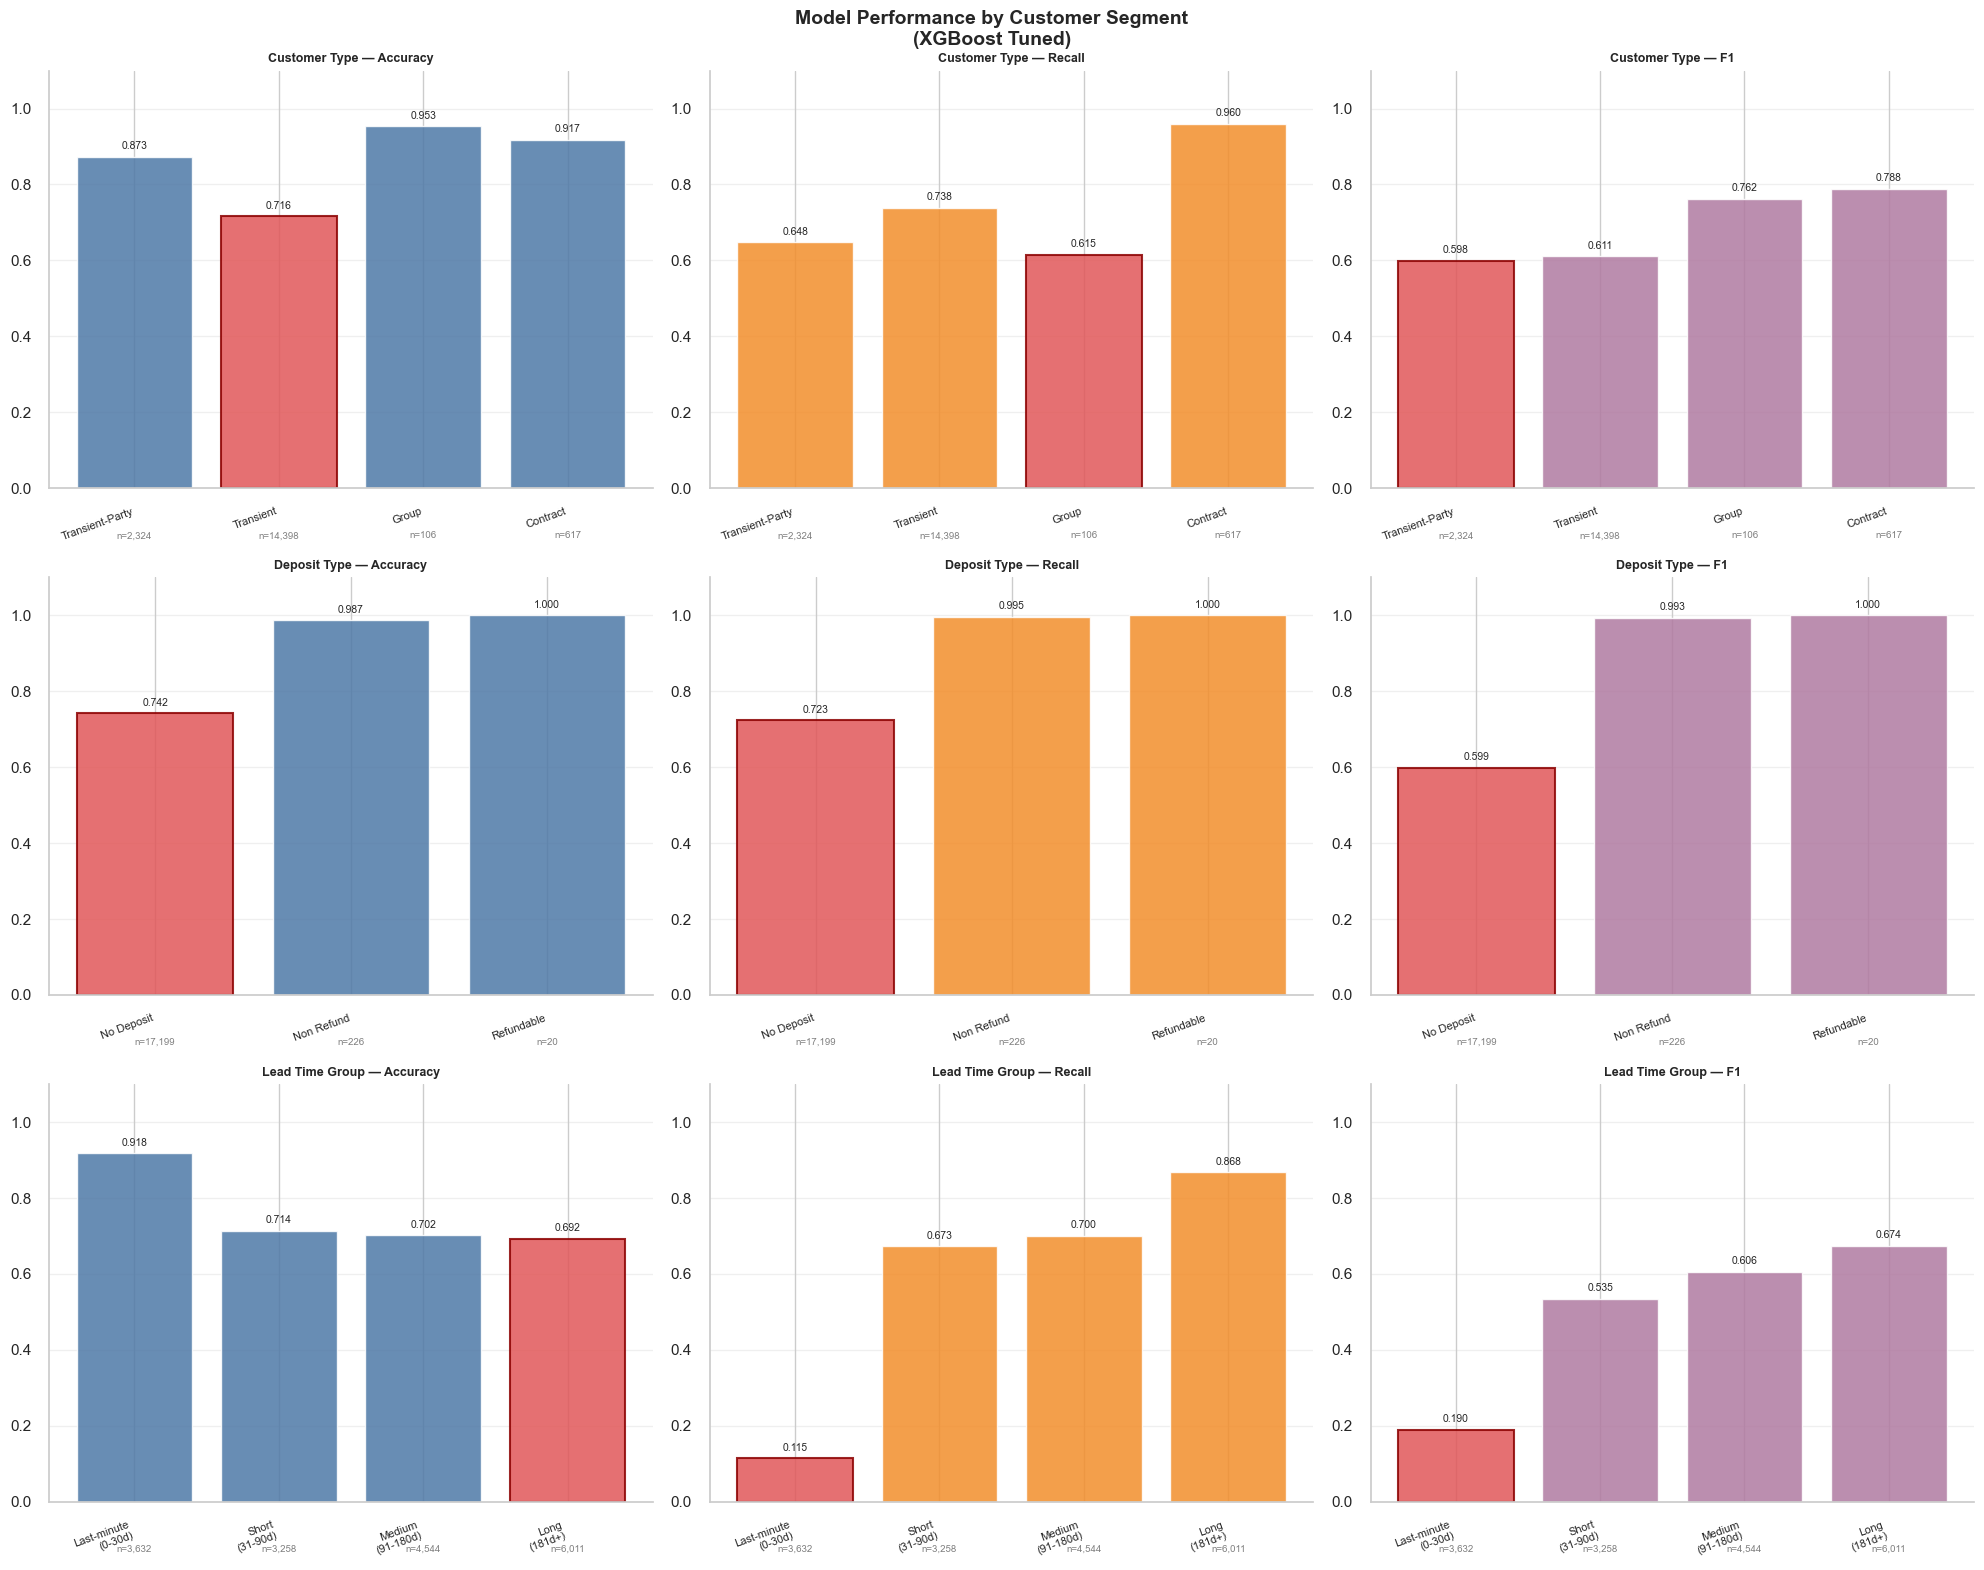


WORST PERFORMING SEGMENTS (Lowest F1)

  Customer Type:
    Segment   : Transient-Party
    Count     : 2,324
    F1        : 0.598
    Recall    : 0.648
    Accuracy  : 0.873

  Deposit Type:
    Segment   : No Deposit
    Count     : 17,199
    F1        : 0.599
    Recall    : 0.723
    Accuracy  : 0.742

  Lead Time Group:
    Segment   : Last-minute
(0-30d)
    Count     : 3,632
    F1        : 0.190
    Recall    : 0.115
    Accuracy  : 0.918


In [39]:
# PART B — Error Analysis: Step 4 — Confusion Matrix Deep Dive by Segment

# Analyse model performance broken down by customer_type, lead_time_group,
# and deposit_type to identify which segments are hardest to predict.

# STEP 1 — BUILD ANALYSIS DATAFRAME

df_analysis = X_test.copy()
df_analysis['actual']    = y_test.values
df_analysis['predicted'] = y_pred_tuned   # using tuned XGBoost

# Label encode back to readable names for display
customer_map    = {0: 'Contract', 1: 'Group', 2: 'Transient', 3: 'Transient-Party'}
deposit_map     = {0: 'No Deposit', 1: 'Non Refund', 2: 'Refundable'}
lead_time_map   = {0: 'Last-minute\n(0-30d)', 1: 'Short\n(31-90d)',
                   2: 'Medium\n(91-180d)', 3: 'Long\n(181d+)'}

df_analysis['customer_label']   = df_analysis['customer_type'].map(customer_map)
df_analysis['deposit_label']    = df_analysis['deposit_type'].map(deposit_map)
df_analysis['lead_time_label']  = df_analysis['lead_time_group'].map(lead_time_map)


# STEP 2 — SEGMENT PERFORMANCE FUNCTION

def segment_metrics(df, group_col):
    """Compute accuracy, cancellation recall, and F1 per segment group."""
    results = []
    for group, subset in df.groupby(group_col):
        if len(subset) < 10:   # skip very small groups
            continue
        actual    = subset['actual']
        predicted = subset['predicted']
        results.append({
            'Segment'   : group,
            'Count'     : len(subset),
            'Cancel %'  : actual.mean(),
            'Accuracy'  : accuracy_score(actual, predicted),
            'Recall'    : recall_score(actual, predicted, zero_division=0),
            'Precision' : precision_score(actual, predicted, zero_division=0),
            'F1'        : f1_score(actual, predicted, zero_division=0),
        })
    return pd.DataFrame(results).sort_values('F1')


# STEP 3 — COMPUTE METRICS PER SEGMENT

df_customer   = segment_metrics(df_analysis, 'customer_label')
df_deposit    = segment_metrics(df_analysis, 'deposit_label')
df_lead_time  = segment_metrics(df_analysis, 'lead_time_label')

print("── Performance by Customer Type ──")
print(df_customer.to_string(index=False, float_format='{:.3f}'.format))
print("\n── Performance by Deposit Type ──")
print(df_deposit.to_string(index=False, float_format='{:.3f}'.format))
print("\n── Performance by Lead Time Group ──")
print(df_lead_time.to_string(index=False, float_format='{:.3f}'.format))


# STEP 4 — VISUALISATIONS

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Model Performance by Customer Segment\n(XGBoost Tuned)',
             fontsize=14, fontweight='bold')

segment_dfs    = [df_customer,  df_deposit,    df_lead_time]
segment_titles = ['Customer Type', 'Deposit Type', 'Lead Time Group']
metric_cols    = ['Accuracy', 'Recall', 'F1']
metric_colors  = ['#4E79A7', '#F28E2B', '#B07AA1']

for row, (seg_df, seg_title) in enumerate(zip(segment_dfs, segment_titles)):
    for col, (metric, color) in enumerate(zip(metric_cols, metric_colors)):
        ax = axes[row][col]

        bars = ax.bar(seg_df['Segment'], seg_df[metric],
                      color=color, alpha=0.85, edgecolor='white')

        # Highlight the worst performing segment in red
        min_idx = seg_df[metric].idxmin()
        min_pos = seg_df.index.get_loc(min_idx)
        bars[min_pos].set_color('#E15759')
        bars[min_pos].set_edgecolor('darkred')
        bars[min_pos].set_linewidth(1.5)

        ax.set_title(f'{seg_title} — {metric}', fontweight='bold', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_xticklabels(seg_df['Segment'], rotation=20, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

        # Label bars with values
        for bar, v in zip(bars, seg_df[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f'{v:.3f}', ha='center', fontsize=7.5)

        # Add sample count below x-axis labels
        for i, (_, row_data) in enumerate(seg_df.iterrows()):
            ax.text(i, -0.12, f'n={row_data["Count"]:,}',
                    ha='center', fontsize=7, color='grey',
                    transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()


# STEP 5 — WORST PERFORMING SEGMENTS SUMMARY

print("\n" + "="*55)
print("WORST PERFORMING SEGMENTS (Lowest F1)")
print("="*55)

for seg_df, seg_title in zip(segment_dfs, segment_titles):
    worst = seg_df.iloc[0]   # already sorted by F1 ascending
    print(f"\n  {seg_title}:")
    print(f"    Segment   : {worst['Segment']}")
    print(f"    Count     : {worst['Count']:,}")
    print(f"    F1        : {worst['F1']:.3f}")
    print(f"    Recall    : {worst['Recall']:.3f}")
    print(f"    Accuracy  : {worst['Accuracy']:.3f}")

### Segment-Level Performance Analysis — Findings

**Results:**

| Segment | F1 | Recall | Notes |
|---------|-----|--------|-------|
| Transient | 0.611 | — | Highest volume segment |
| Transient-Party | 0.598 | 0.648 | Group dynamics make behaviour unpredictable |
| No Deposit | 0.599 | 0.723 | 98% of test set — largest and weakest segment |
| Last-minute | 0.190 | 0.115 | Hardest-to-predict segment |

**Key Findings:**
- **No Deposit** represents the most critical weakness — accounts for 98% of the test set yet achieves only F1 0.599, concentrating nearly all hard-to-predict cancellations → **directly motivated Step 5 (No Deposit Sub-Model)**
- **Last-minute bookings** achieve the lowest F1 (0.190) and Recall (0.115) — the model has almost no ability to predict last-minute cancellations, likely due to insufficient distinguishing features for this segment
- **Transient-Party** customers show persistently weak performance (F1 0.598) — group booking dynamics introduce unpredictability that individual-level features cannot fully capture
- **Transient** customers perform best among high-risk segments (F1 0.611) despite being the highest volume group

# 6. Final Solution & Business Insights

## 6.1 Final Model Selection
- **Primary:** XGBoost (threshold = 0.5165) — F1: 0.616, Recall: 0.708
- **Stability:** Soft Voting Ensemble — Accuracy: 0.770, ROC-AUC: 0.833
- **Baseline:** Random Forest (class_weight = balanced) — interpretable stakeholder communication

## 6.2 Key Predictive Factors
Top five predictors across all three models: lead_time_group, has_parking_request, 
customer_type, is_portugal, deposit_type (No Deposit).
Full analysis in report Section 6.2.

## 6.3 Cost Saving Calculation
Revenue recoverable through proactive retention actions on correctly predicted cancellations:
- Revenue at risk per booking: €106.52 × 3.63 = **€386.67**
- Total potential loss (no model): 4,802 × €386.67 = **€1,857,791**
- Detectable revenue at risk (TP = 3,402): **€1,315,813**
- Equivalent to 70.80% of cancellations detected, 19.30% of total test revenue

In [45]:
# Calculate average ADR and average total stay
print(f"Average ADR          : {df['adr'].mean():.2f}")
print(f"Average Total Stay   : {df['total_stay'].mean():.2f}")
print(f"Total Cancellations in Test Set      : {y_test.sum()}")
print(f"Correctly Predicted Cancellations (TP): {((y_pred_best_t == 1) & (y_test == 1)).sum()}")

Average ADR          : 106.52
Average Total Stay   : 3.63
Total Cancellations in Test Set      : 4802
Correctly Predicted Cancellations (TP): 3402


In [47]:
# Calculate total revenue in test set
total_revenue = (df.loc[X_test.index, 'adr'] * X_test['total_stay']).sum()
print(f"Total Revenue in Test Set : €{total_revenue:,.2f}")

Total Revenue in Test Set : €6,821,387.79


## 6.4 Business Recommendations
Five targeted retention strategies across high-risk segments identified in 
Sections 6.2 and 5.2. Full details in report Section 6.4.

## 6.5 Limitations, Risks & Next Steps
- Dataset covers 2015–2017 only, one city hotel and one resort hotel
- Absence of external contextual signals limits No Deposit prediction (F1 0.599)
- Last-minute bookings remain structurally weak (F1 0.190)
- Requires periodic retraining as booking behaviours evolve

Full details in report Section 6.5.